# Drift Detection — Control Sample (LCS) Analysis

Detects **gradual drift** in laboratory control sample measurements for a given `STD_LOT_CODE`.

**Method**  
For each analyte within the lot:
1. Measurements are sorted chronologically.
2. Each value is normalised against the warning bounds:  
   `norm_dev = (value − target) / (warning_bound − target)`  
   where `warning_bound` is `INTERNAL_MAX_WARNING_VALUE` when value ≥ target, else `INTERNAL_MIN_WARNING_VALUE`.  
   A score of **0** means exactly on target; **±1** means at the warning boundary.
3. A rolling mean of `norm_dev` is computed.
4. **Drift is flagged** when the rolling mean exceeds `DRIFT_THRESHOLD` in magnitude for at least `CONSECUTIVE_REQUIRED` consecutive observations.

**Outputs per analyte**  
- `drift_detected` — boolean flag  
- `drift_direction` — `Upper` (trending high) or `Lower` (trending low)  
- `drift_start` — timestamp of the first observation in the drift sequence  
- `severity_score` — absolute rolling mean at the last observation (0 = on target, 1 = at warning bound)  
- Time-series plot

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

## 1. Load Data

In [3]:
df = pd.read_csv("Data/ResultSet.csv")
df.columns = [c.strip().upper() for c in df.columns]

for col in ["NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
            "INTERNAL_MAX_WARNING_VALUE", "INTERNAL_MIN_WARNING_VALUE",
            "INTERNAL_MAX_VALUE", "INTERNAL_MIN_VALUE"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["ANALYSED_DATE"] = pd.to_datetime(df["ANALYSED_DATE"], errors="coerce")

print(f"Loaded {len(df):,} rows")
print("Available STD_LOT_CODEs:")
print(df[df["ANALYTICAL_TYPE"] == "Standard"]["STD_LOT_CODE"].value_counts().to_string())

Loaded 99,999 rows
Available STD_LOT_CODEs:
STD_LOT_CODE
Sample        6958
OREAS_905     5661
OREAS_62F     5551
OREAS_501C    5410
OREAS_503C    4305
OREAS_624     4299
OREAS_522     1122
OREAS_139     1013
OREAS_908      735
OREAS_524      519
OREAS_503D     225
OREAS_351      205
OREAS_20A      164
OREAS_98       157
OREAS_623      136
OREAS_621       61
OREAS_505       58
OREAS_520       26
OREAS_136       25
OREAS_38        21
OREAS_45F       10
OREAS_45H       10
OREAS_622       10
OREAS_605        6


In [11]:
display(df[df["ANALYTICAL_TYPE"] == "Standard"])


,ANALYTICAL_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,PRECISION_STATUS,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MIN_INCLUSIVE,INTERNAL_MAX_INCLUSIVE,INTERNAL_MAX_WARNING_VALUE,INTERNAL_MIN_WARNING_VALUE,INTERNAL_MIN_WARNING_INCLUSIVE,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE,UNIT_CODE,SPECIFICATION_CODE,INSTRUMENT_ID
0,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,35.927171,2021-11-22 16:37:52,GE_IMS40Q12,PB,UpperFailure,NaN,26.110560,34.689440,Y,Y,33.120800,27.679200,Y,Y,10,1.250,15.0,1.250,30.40,NaN,MG_KG,OREAS_905,NaN
1,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,55.639610,2021-11-22 16:37:52,GE_IMS40Q12,PB,UpperFailure,NaN,26.110560,34.689440,Y,Y,33.120800,27.679200,Y,Y,10,1.250,15.0,1.250,30.40,NaN,MG_KG,OREAS_905,NaN
4,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,11.742601,2021-11-22 16:37:33,GE_IMS40Q12,NI,UpperWarning,NaN,7.336260,11.743740,Y,Y,10.937610,8.142390,Y,Y,10,5.000,15.0,5.000,9.54,NaN,MG_KG,OREAS_905,NaN
5,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,12.236060,2021-11-22 16:37:33,GE_IMS40Q12,NI,UpperFailure,NaN,7.336260,11.743740,Y,Y,10.937610,8.142390,Y,Y,10,5.000,15.0,5.000,9.54,NaN,MG_KG,OREAS_905,NaN
7,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,1501.882410,2021-11-22 16:35:49,GE_IMS40Q12,CU,Pass,NaN,1379.700000,1686.300000,Y,Y,1630.192200,1435.807800,Y,Y,10,5.000,15.0,5.000,1533.00,NaN,MG_KG,OREAS_905,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99989,Standard,OREAS_624,OREAS_624,TSV_LB0002628992,35.660377,2020-06-26 02:50:23,GE_IMS40Q12,SE,UpperWarning,NaN,22.090390,38.109610,Y,Y,35.180880,25.019120,Y,Y,10,5.000,15.0,5.000,30.10,NaN,MG_KG,OREAS_624,NaN
99994,Standard,OREAS_501C,OREAS_501C,TSV_LB0002628992,24.835165,2020-06-26 02:40:42,GE_IMS40Q12,AS,Pass,NaN,21.010490,26.789510,Y,Y,25.733130,22.066870,Y,Y,10,2.500,15.0,2.500,23.90,NaN,MG_KG,OREAS_501C,NaN
99995,Standard,OREAS_501C,OREAS_501C,TSV_LB0002628992,2.263736,2020-06-26 02:40:42,GE_IMS40Q12,SE,Pass,NaN,-3.137085,7.277085,Y,Y,5.372892,-1.232892,Y,Y,10,5.000,15.0,5.000,2.07,NaN,MG_KG,OREAS_501C,NaN
99996,Standard,OREAS_501C,OREAS_501C,TSV_LB0002628992,0.675824,2020-06-26 02:40:42,GE_IMS40Q12,BI,Pass,NaN,0.521019,0.858981,Y,Y,0.797157,0.582843,Y,Y,10,0.100,15.0,0.100,0.69,NaN,MG_KG,OREAS_501C,NaN


In [13]:
print(df[df["ANALYTICAL_TYPE"] == "Standard" ]["JOB_CODE"].value_counts().to_string())

JOB_CODE
TSV_LB0005186144    517
TSV_LB0009017856    476
TSV_LB0005485209    443
TSV_LB0002166658    348
TSV_LB0005394796    345
TSV_LB0005186285    345
TSV_LB0004988884    344
TSV_LB0004644915    344
TSV_LB0006066326    339
TSV_LB0005815864    335
TSV_LB0006065731    334
TSV_LB0005815959    334
TSV_LB0006065977    332
TSV_LB0005485336    330
TSV_LB0004352211    326
TSV_LB0004351915    326
TSV_LB0000449085    299
TSV_LB0005816034    259
TSV_LB0004797379    237
TSV_LB0006205235    231
TSV_LB0006482952    225
TSV_LB0003203766    218
TSV_LB0000666551    202
TSV_LB0004328823    199
TSV_LB0007353557    187
TSV_LB0002908076    178
TSV_LB0006483071    175
TSV_LB0005394901    172
TSV_LB0004988975    172
TSV_LB0010628748    171
TSV_LB0006934526    170
TSV_LB0004352597    166
TSV_LB0002875057    164
TSV_LB0004456358    164
TSV_LB0004645020    163
TSV_LB0004835620    161
TSV_LB0004023226    161
TSV_LB0007340966    160
TSV_LB0004797270    160
TSV_LB0007341084    159
TSV_LB0006482847    159
TSV_LB0

## 2. Configuration

Set `STD_LOT_CODE` to the lot you want to analyse.  
Tune the drift parameters as needed.

In [ ]:
# ── INPUT ────────────────────────────────────────────────────────────────────
STD_LOT_CODE = "OREAS_905"   # change to any STD_LOT_CODE from the list above
JOB_CODE = 'TSV_LB0005186144'

# ── DRIFT PARAMETERS ─────────────────────────────────────────────────────────
ROLLING_WINDOW     = 10   # number of observations for the rolling mean
DRIFT_THRESHOLD    = 0.5  # fraction of the way from target to warning bound
CONSECUTIVE_REQUIRED = 3  # how many consecutive rolling-mean breaches = drift

## 3. Drift Detection

In [ ]:
def detect_drift(df: pd.DataFrame,
                 std_lot_code: str,
                 job_code : str,
                 rolling_window: int = 10,
                 drift_threshold: float = 0.5,
                 consecutive_required: int = 3) -> tuple[pd.DataFrame, dict]:
    """
    Detect drift for all analytes within a given STD_LOT_CODE.

    Returns
    -------
    summary : DataFrame   — one row per analyte with drift results
    analyte_data : dict   — {analyte: per-observation DataFrame} for plotting
    """
    required_cols = [
        "ANALYTICAL_TYPE", "STD_LOT_CODE", "ANALYTE_CODE", "ANALYSED_DATE",
        "NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
        "INTERNAL_MAX_WARNING_VALUE", "INTERNAL_MIN_WARNING_VALUE",
    ]

    lot_df = (
        df[
            (df["ANALYTICAL_TYPE"] == "Standard") &
            (df["STD_LOT_CODE"] == std_lot_code) 
        ]
        .dropna(subset=required_cols)
        .copy()
    )

    if lot_df.empty:
        raise ValueError(f"No Standard rows found for STD_LOT_CODE='{std_lot_code}'")

    summary_rows = []
    analyte_data = {}

    for analyte, adf in lot_df.groupby("ANALYTE_CODE"):
        adf = adf.sort_values("ANALYSED_DATE").reset_index(drop=True)

        target   = adf["INTERNAL_TARGET_VALUE"]
        max_warn = adf["INTERNAL_MAX_WARNING_VALUE"]
        min_warn = adf["INTERNAL_MIN_WARNING_VALUE"]
        value    = adf["NUMERIC_FINAL_VALUE"]

        upper_range = (max_warn - target).replace(0, np.nan)
        lower_range = (target - min_warn).replace(0, np.nan)

        # Positive norm_dev = drifting high; negative = drifting low
        adf["norm_dev"] = np.where(
            value >= target,
            (value - target) / upper_range,
            (value - target) / lower_range,   # negative when below target
        )

        win = min(rolling_window, len(adf))
        adf["rolling_norm_dev"] = (
            adf["norm_dev"]
            .rolling(window=win, min_periods=max(1, win // 2))
            .mean()
        )

        # ── Find first run of `consecutive_required` breaches ────────────────
        drift_detected  = False
        drift_direction = None
        drift_start     = pd.NaT
        run_start_idx   = None
        run_len         = 0

        for i, rnd in enumerate(adf["rolling_norm_dev"]):
            if pd.isna(rnd):
                run_len = 0
                run_start_idx = None
                continue

            if abs(rnd) >= drift_threshold:
                if run_len == 0:
                    run_start_idx = i
                run_len += 1
                if run_len >= consecutive_required and not drift_detected:
                    drift_detected  = True
                    drift_direction = "Upper" if rnd > 0 else "Lower"
                    drift_start     = adf.loc[run_start_idx, "ANALYSED_DATE"]
            else:
                run_len = 0
                run_start_idx = None

        last_rnd = adf["rolling_norm_dev"].dropna()
        severity_score = float(abs(last_rnd.iloc[-1])) if not last_rnd.empty else np.nan

        # ── First warning / failure dates from STANDARD_STATUS ───────────────
        if "STANDARD_STATUS" in adf.columns:
            warn_mask = (
                adf["STANDARD_STATUS"].str.contains("Warning", na=False) &
                ~adf["STANDARD_STATUS"].str.contains("Ignored", na=False)
            )
            fail_mask = (
                adf["STANDARD_STATUS"].str.contains("Failure", na=False) &
                ~adf["STANDARD_STATUS"].str.contains("Ignored", na=False)
            )
            first_warning_date = adf.loc[warn_mask, "ANALYSED_DATE"].min() if warn_mask.any() else pd.NaT
            first_failure_date = adf.loc[fail_mask, "ANALYSED_DATE"].min() if fail_mask.any() else pd.NaT
        else:
            first_warning_date = pd.NaT
            first_failure_date = pd.NaT

        summary_rows.append({
            "ANALYTE_CODE"      : analyte,
            "drift_detected"    : drift_detected,
            "drift_direction"   : drift_direction,
            "drift_start"       : drift_start,
            "severity_score"    : round(severity_score, 4),
            "first_warning_date": first_warning_date,
            "first_failure_date": first_failure_date,
            "n_observations"    : len(adf),
        })
        analyte_data[analyte] = adf

    summary = (
        pd.DataFrame(summary_rows)
        .sort_values(["drift_detected", "severity_score"], ascending=[False, False])
        .reset_index(drop=True)
    )
    return summary, analyte_data

## 4. Run & Summary

In [7]:
summary, analyte_data = detect_drift(
    df,
    std_lot_code        = STD_LOT_CODE,
    rolling_window      = ROLLING_WINDOW,
    drift_threshold     = DRIFT_THRESHOLD,
    consecutive_required= CONSECUTIVE_REQUIRED,
)

n_drifting = summary["drift_detected"].sum()
print(f"STD_LOT_CODE     : {STD_LOT_CODE}")
print(f"Analytes checked : {len(summary)}")
print(f"Drift detected   : {n_drifting}")
print()

def _fmt_dt(v):
    return v.strftime("%Y-%m-%d") if pd.notna(v) else "—"

def _style_row(row):
    if row["drift_detected"]:
        color = "#ffd6d6" if row["severity_score"] >= 1.0 else "#fff0cc"
    elif pd.notna(row["first_failure_date"]):
        color = "#ffe0e0"
    elif pd.notna(row["first_warning_date"]):
        color = "#fff8e1"
    else:
        color = ""
    return [f"background-color: {color}" if color else "" for _ in row]

display(
    summary.style
    .apply(_style_row, axis=1)
    .format({
        "severity_score"    : "{:.4f}",
        "drift_start"       : _fmt_dt,
        "first_warning_date": _fmt_dt,
        "first_failure_date": _fmt_dt,
    })
    .set_caption(f"Drift summary — {STD_LOT_CODE}")
)

STD_LOT_CODE     : OREAS_905
Analytes checked : 57
Drift detected   : 45



,ANALYTE_CODE,drift_detected,drift_direction,drift_start,severity_score,first_warning_date,first_failure_date,n_observations
0,EU,True,Upper,2020-12-03,2.3369,2021-01-28,2021-01-05,22
1,AG,True,Upper,2020-07-13,1.9851,2020-06-29,2020-07-02,366
2,IN,True,Lower,2021-01-21,1.3727,2020-12-15,2021-01-05,20
3,SB,True,Upper,2020-07-29,1.0376,2020-07-09,2020-06-29,355
4,PR,True,Lower,2020-12-15,1.0297,2020-12-03,2021-01-05,20
5,U,True,Lower,2020-12-07,0.9525,2020-12-15,2020-12-07,36
6,BI,True,Lower,2020-07-03,0.9231,2020-07-03,2020-06-29,349
7,NB,True,Lower,2021-01-05,0.9089,2020-10-13,2021-01-05,20
8,SM,True,Lower,2021-02-02,0.8826,2020-12-15,2021-01-05,19
9,V,True,Upper,2020-12-07,0.8624,2020-12-07,—,20


## 5. Time-Series Plots

One plot per analyte. Grey band = warning zone, red dashed = failure bounds.  
Orange line = rolling normalised deviation (right-hand axis).  
Orange shading marks the drift period once detected.

In [8]:
STATUS_COLORS = {
    "Pass"               : "#1565C0",   # blue
    "UpperWarning"       : "#EF6C00",   # orange
    "LowerWarning"       : "#FF8F00",   # amber
    "UpperFailure"       : "#C62828",   # red
    "LowerFailure"       : "#AD1457",   # dark pink
    "IgnoredUpperFailure": "#9E9E9E",   # grey
    "IgnoredLowerFailure": "#BDBDBD",   # light grey
}

def _fmt_date(dt):
    return dt.strftime("%Y-%m-%d") if pd.notna(dt) else "—"


def plot_analyte_drift(adf: pd.DataFrame,
                       analyte: str,
                       std_lot_code: str,
                       drift_info: dict,
                       drift_threshold: float = 0.5) -> None:
    """Time-series plot of measurements coloured by STANDARD_STATUS + rolling normalised deviation."""
    fig, ax1 = plt.subplots(figsize=(14, 5))

    dates = adf["ANALYSED_DATE"]

    # ── Reference values (constant per analyte; take first non-null) ─────────
    def _first(col):
        s = adf[col].dropna() if col in adf.columns else pd.Series(dtype=float)
        return float(s.iloc[0]) if not s.empty else None

    target   = _first("INTERNAL_TARGET_VALUE")
    max_warn = _first("INTERNAL_MAX_WARNING_VALUE")
    min_warn = _first("INTERNAL_MIN_WARNING_VALUE")
    max_fail = _first("INTERNAL_MAX_VALUE")
    min_fail = _first("INTERNAL_MIN_VALUE")

    # Warning band (shaded)
    if max_warn is not None and min_warn is not None:
        ax1.axhspan(min_warn, max_warn, color="#ffe0a0", alpha=0.25, label="Warning zone")

    # Failure bounds
    for val, lbl in [(max_fail, "Failure bound"), (min_fail, None)]:
        if val is not None:
            ax1.axhline(val, color="red", linestyle="--", linewidth=1.0, alpha=0.7,
                        label=lbl if lbl else "_nolegend_")

    # Warning bounds
    for val in [max_warn, min_warn]:
        if val is not None:
            ax1.axhline(val, color="orange", linestyle="-.", linewidth=1.0, alpha=0.9,
                        label="Warning bound" if val == max_warn else "_nolegend_")

    # Target line
    if target is not None:
        ax1.axhline(target, color="#2E7D32", linestyle="-", linewidth=1.5, alpha=0.8,
                    label=f"Target ({target:.3g})")

    # ── Scatter points coloured by STANDARD_STATUS ───────────────────────────
    if "STANDARD_STATUS" in adf.columns:
        plot_df = adf.copy()
        plot_df["STANDARD_STATUS"] = plot_df["STANDARD_STATUS"].fillna("Pass").astype(str)
        present_statuses = plot_df["STANDARD_STATUS"].unique()

        for status in present_statuses:
            grp = plot_df[plot_df["STANDARD_STATUS"] == status]
            color = STATUS_COLORS.get(status, "#607D8B")
            ax1.scatter(grp["ANALYSED_DATE"], grp["NUMERIC_FINAL_VALUE"],
                        s=22, color=color, alpha=0.8, zorder=3, label=status)
    else:
        ax1.scatter(dates, adf["NUMERIC_FINAL_VALUE"],
                    s=22, color="#1565C0", alpha=0.8, zorder=3, label="Pass")

    ax1.set_xlabel("Date")
    ax1.set_ylabel("NUMERIC_FINAL_VALUE")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")

    # ── Right axis: rolling normalised deviation ──────────────────────────────
    ax2 = ax1.twinx()
    ax2.plot(dates, adf["rolling_norm_dev"],
             color="darkorange", linewidth=2.0, label="Rolling norm. dev.", zorder=2)
    ax2.axhline( drift_threshold, color="darkorange", linestyle=":", linewidth=1.0)
    ax2.axhline(-drift_threshold, color="darkorange", linestyle=":", linewidth=1.0)
    ax2.axhline(0, color="grey", linestyle=":", linewidth=0.8)
    ax2.set_ylabel("Rolling norm. deviation  (0 = target, ±1 = warning bound)")
    ax2.set_ylim(-2.5, 2.5)

    # ── Vertical markers: drift start, first warning, first failure ───────────
    vlines = [
        (drift_info.get("drift_start"),       "red",    "--", 1.8, "Drift start"),
        (drift_info.get("first_warning_date"), "orange", "-.", 1.5, "First warning"),
        (drift_info.get("first_failure_date"), "crimson","-", 1.5, "First failure"),
    ]
    ymax = ax1.get_ylim()[1]

    for dt, color, ls, lw, label in vlines:
        if pd.notna(dt):
            ax1.axvline(dt, color=color, linestyle=ls, linewidth=lw, alpha=0.85, zorder=4)
            ax1.text(dt, ymax, f" {label}\n {_fmt_date(dt)}",
                     color=color, fontsize=7, va="top", rotation=90,
                     bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6, ec=color))

    # Drift period shading
    if drift_info.get("drift_detected") and pd.notna(drift_info.get("drift_start")):
        ax1.axvspan(drift_info["drift_start"], dates.iloc[-1],
                    color="red", alpha=0.06)

    # ── Legend (left axis handles + right axis rolling line) ─────────────────
    handles1, labels1 = ax1.get_legend_handles_labels()
    rolling_handle = Line2D([0], [0], color="darkorange", linewidth=2, label="Rolling norm. dev.")
    ax1.legend(
        handles1 + [rolling_handle],
        labels1  + ["Rolling norm. dev."],
        loc="upper left", fontsize=8, framealpha=0.85,
        ncol=2
    )

    status_text = (
        f"DRIFT — {drift_info['drift_direction']} | "
        f"Drift start: {_fmt_date(drift_info.get('drift_start'))} | "
        f"First warning: {_fmt_date(drift_info.get('first_warning_date'))} | "
        f"First failure: {_fmt_date(drift_info.get('first_failure_date'))} | "
        f"Severity: {drift_info['severity_score']:.3f}"
        if drift_info.get("drift_detected")
        else (
            f"No drift | "
            f"First warning: {_fmt_date(drift_info.get('first_warning_date'))} | "
            f"First failure: {_fmt_date(drift_info.get('first_failure_date'))} | "
            f"Severity: {drift_info['severity_score']:.3f}"
        )
    )
    title_color = "red" if drift_info.get("drift_detected") else "#2E7D32"
    ax1.set_title(
        f"{std_lot_code} — {analyte}  |  {status_text}",
        fontsize=10, color=title_color, fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

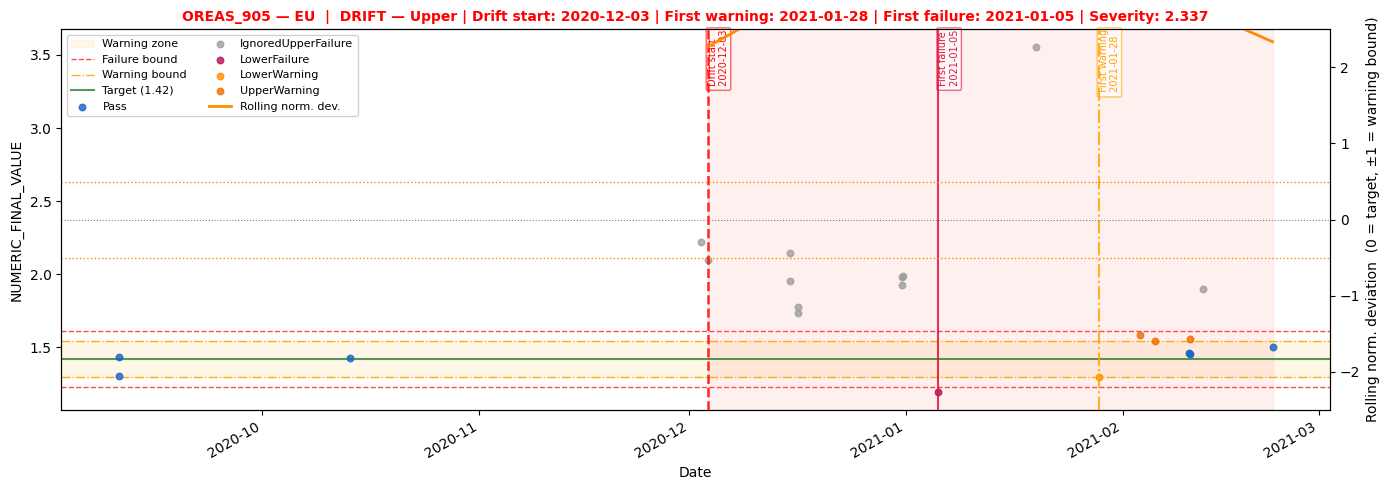

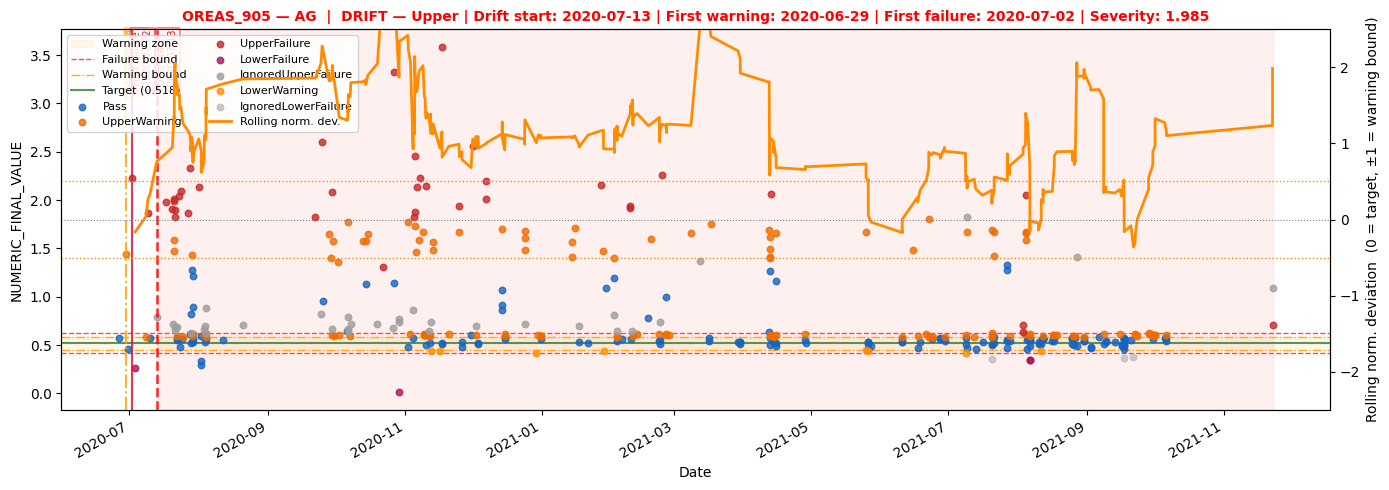

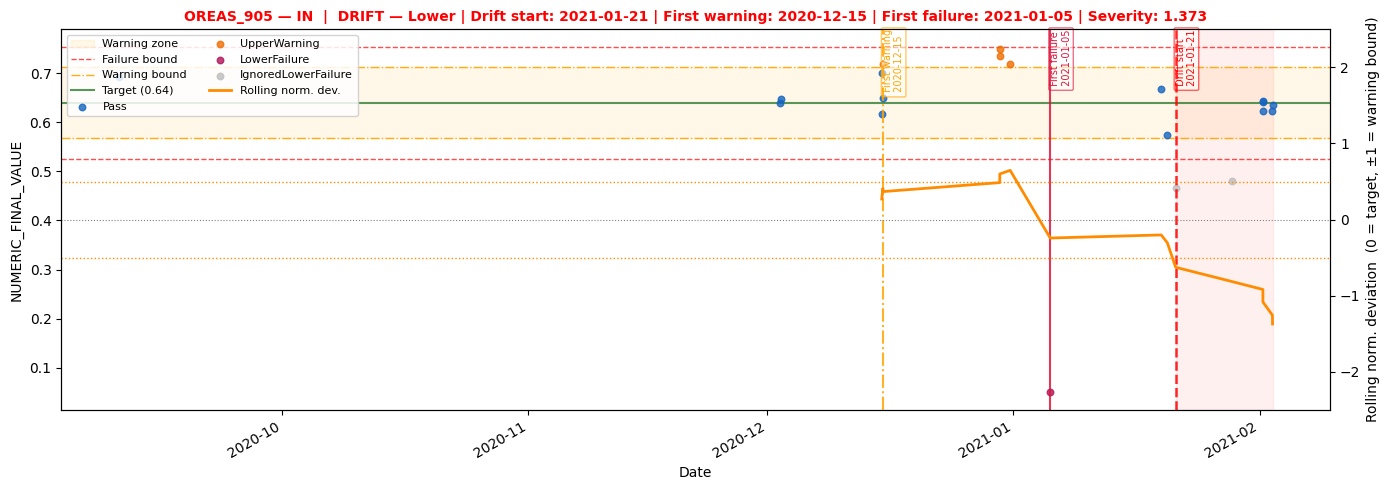

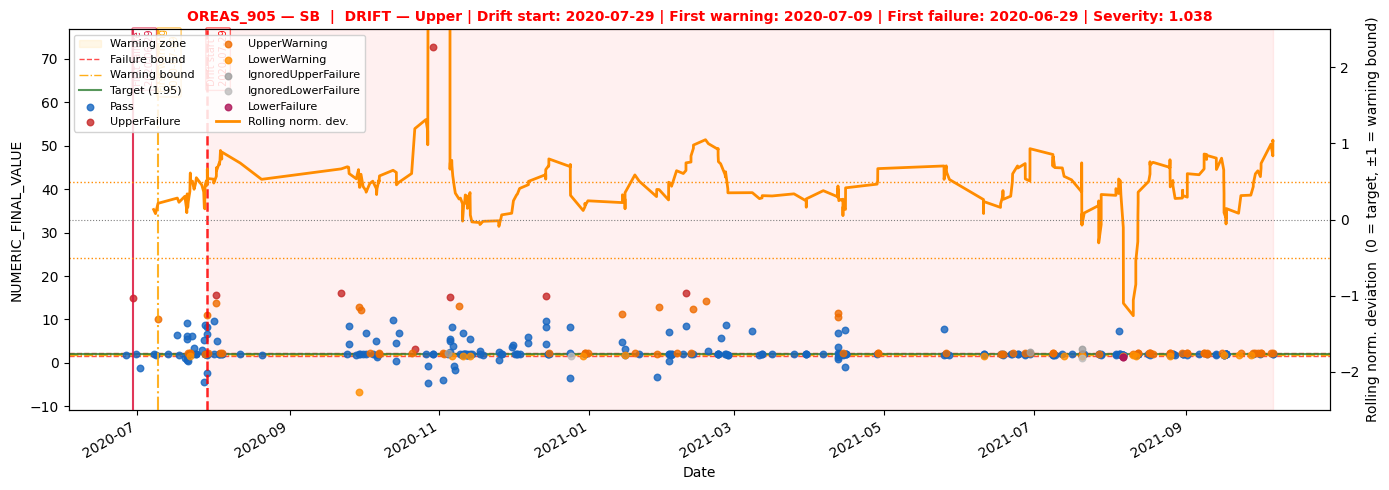

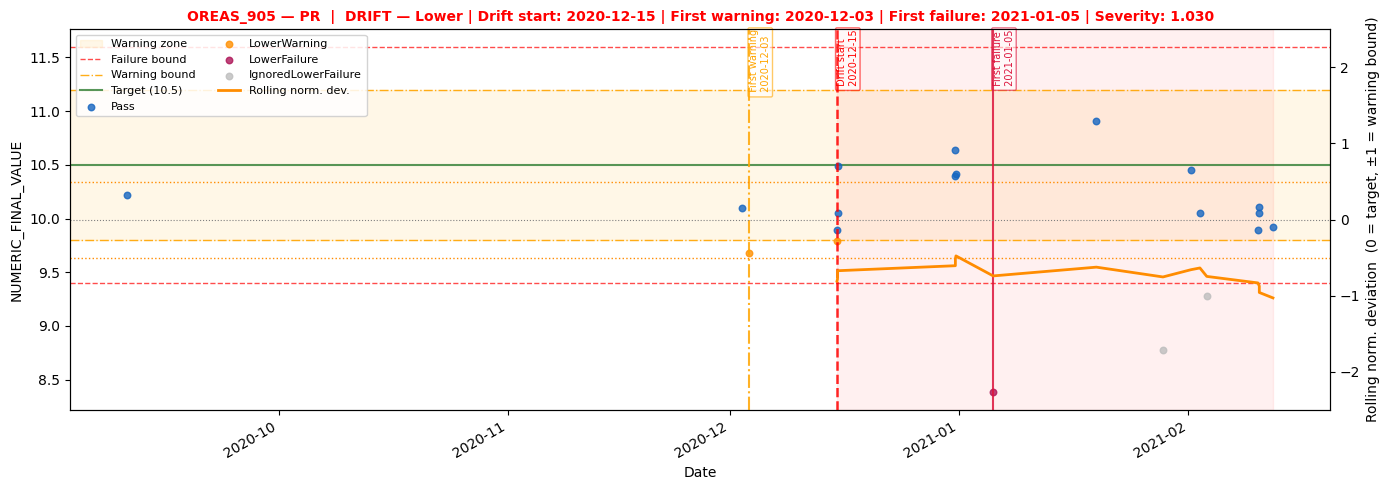

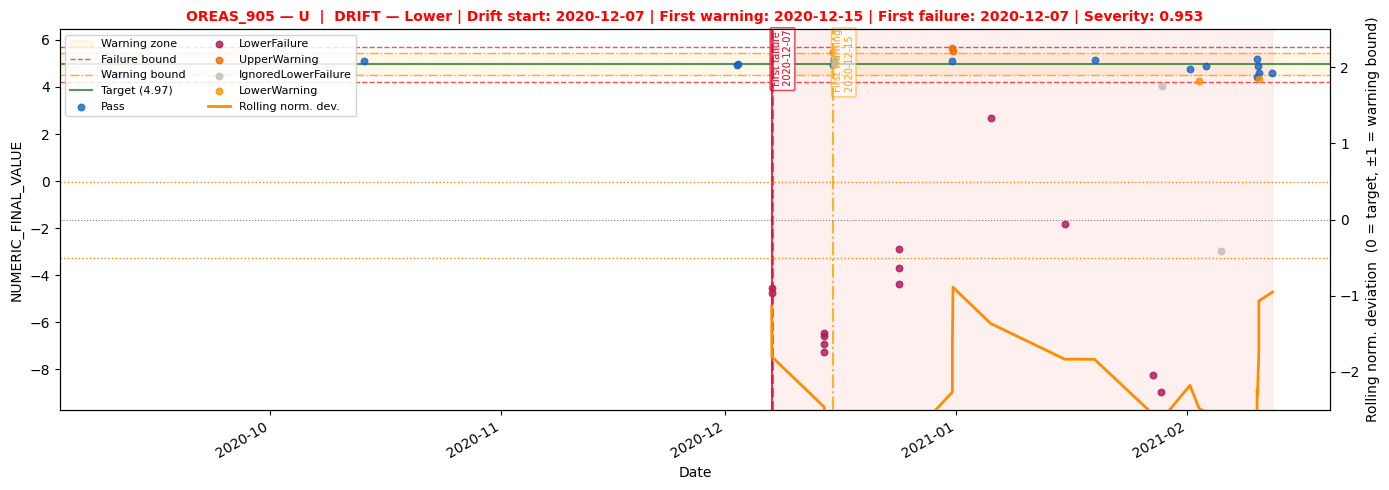

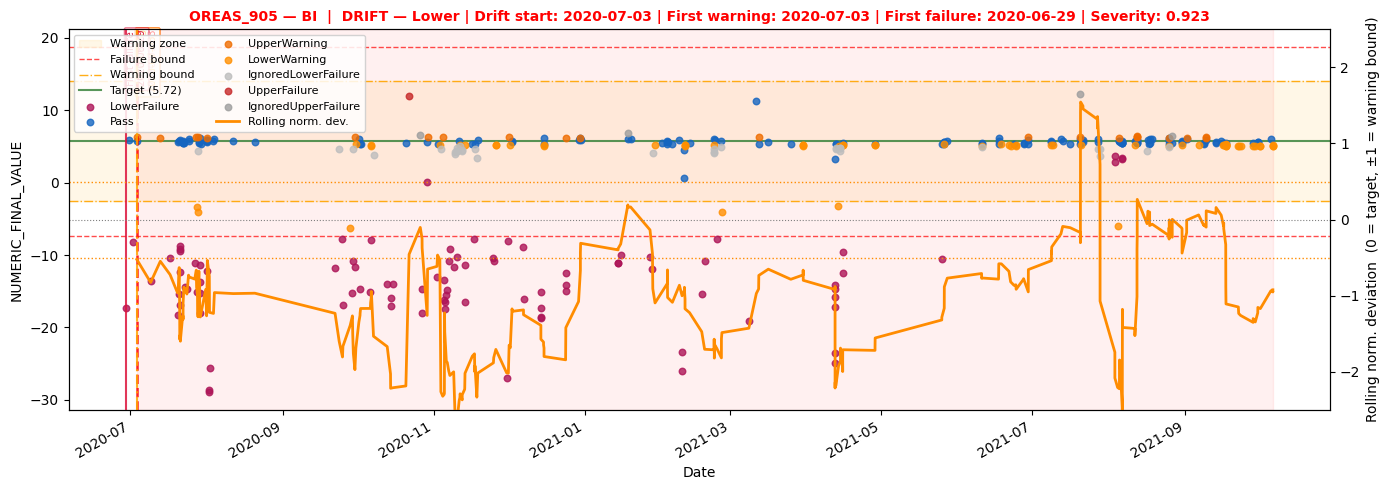

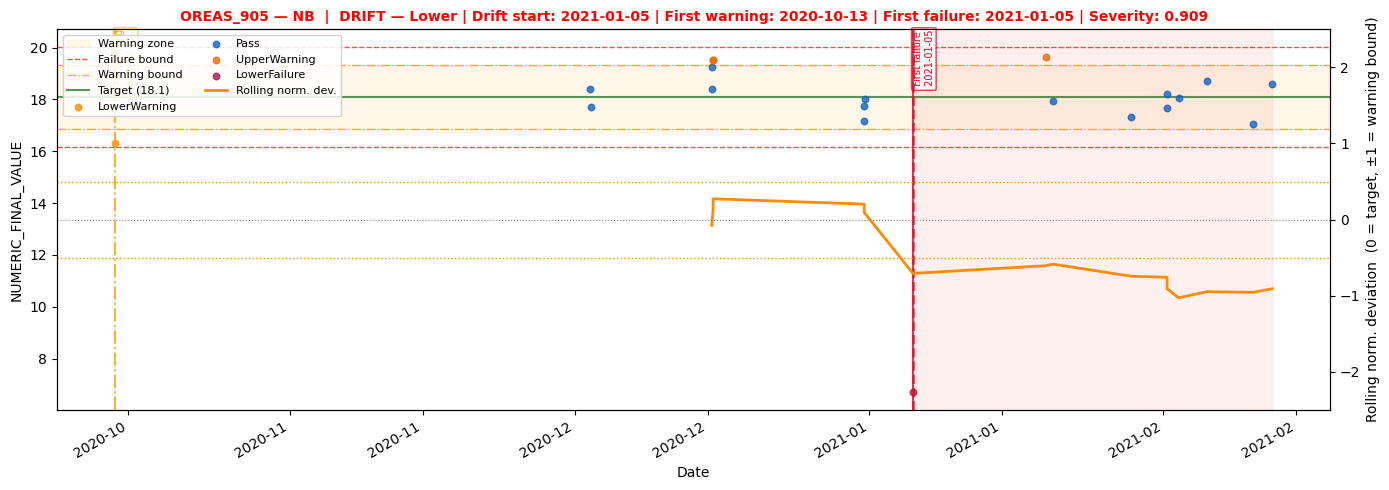

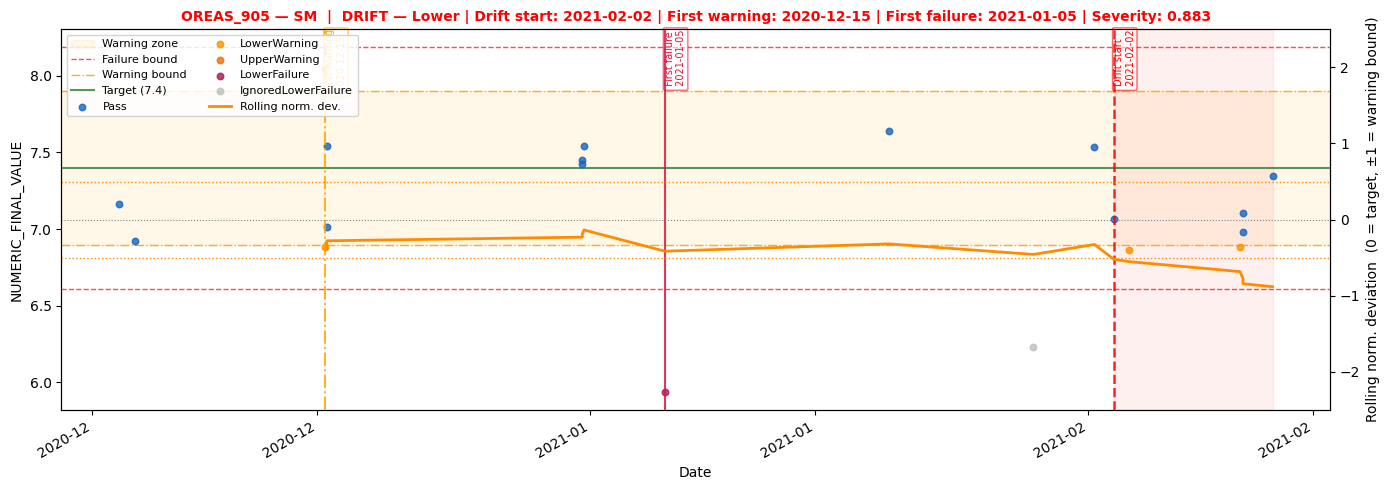

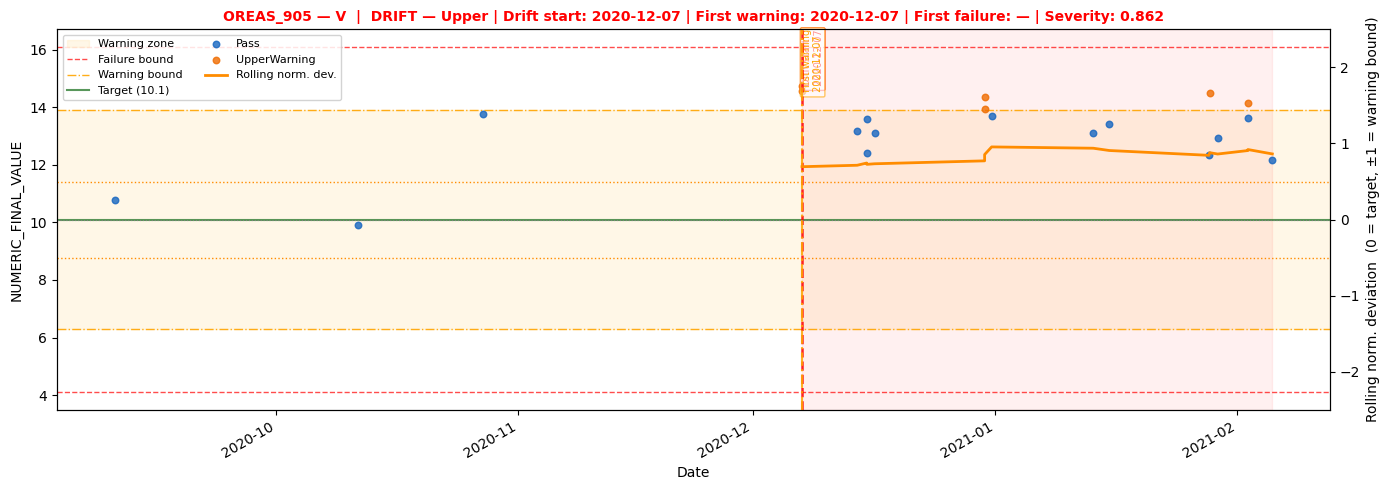

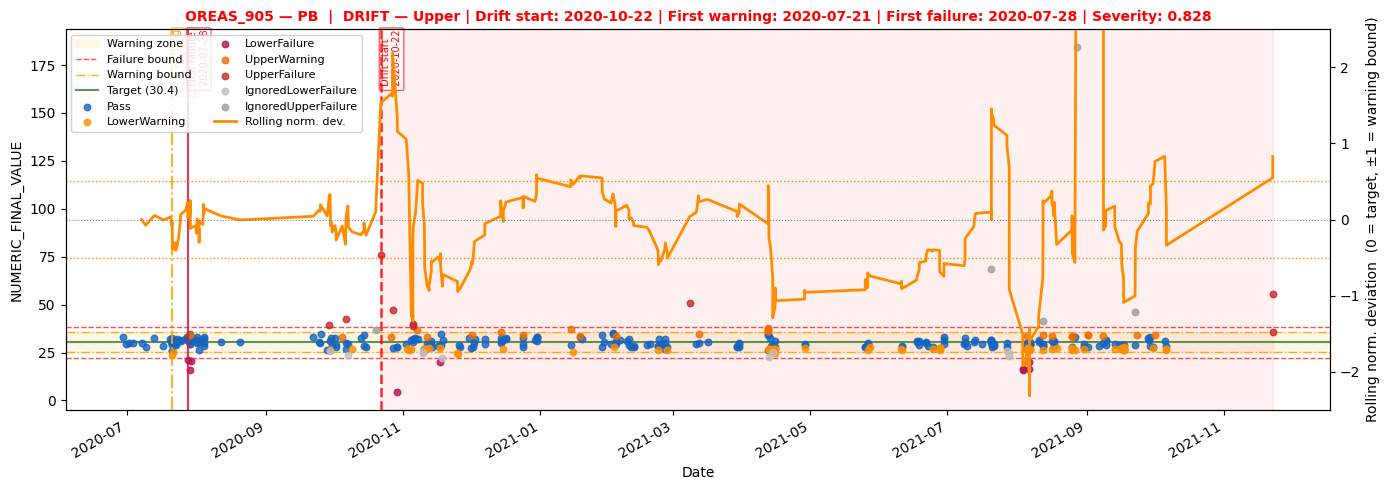

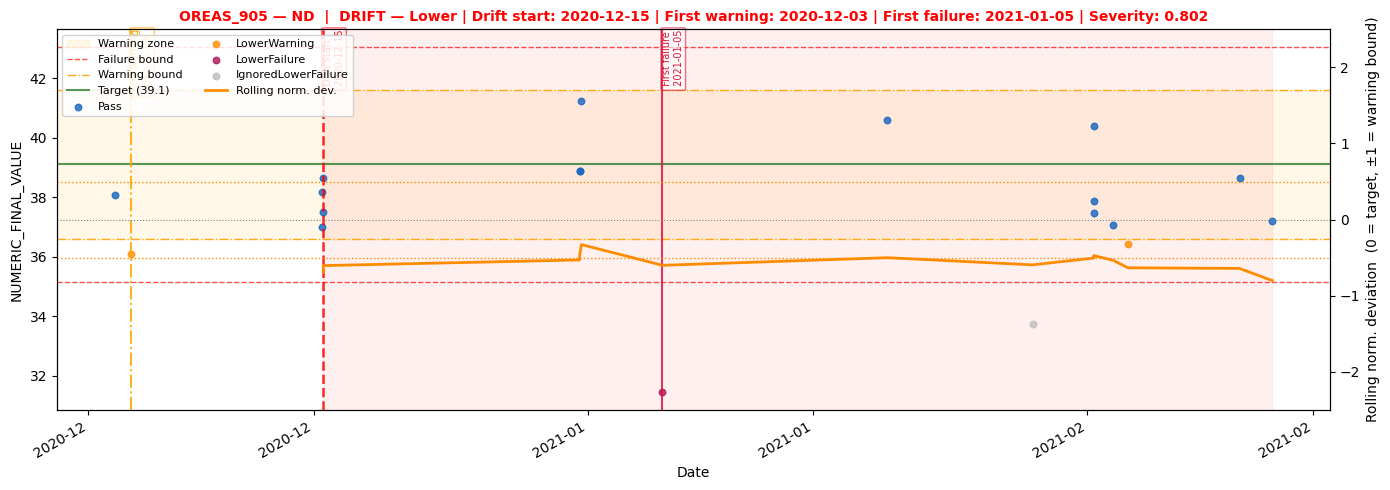

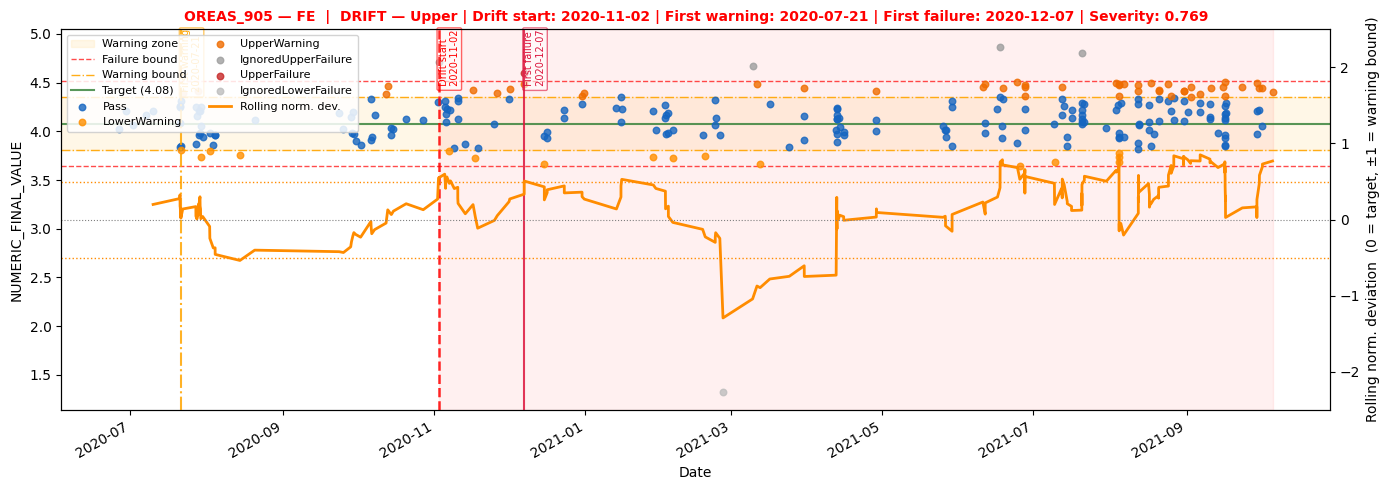

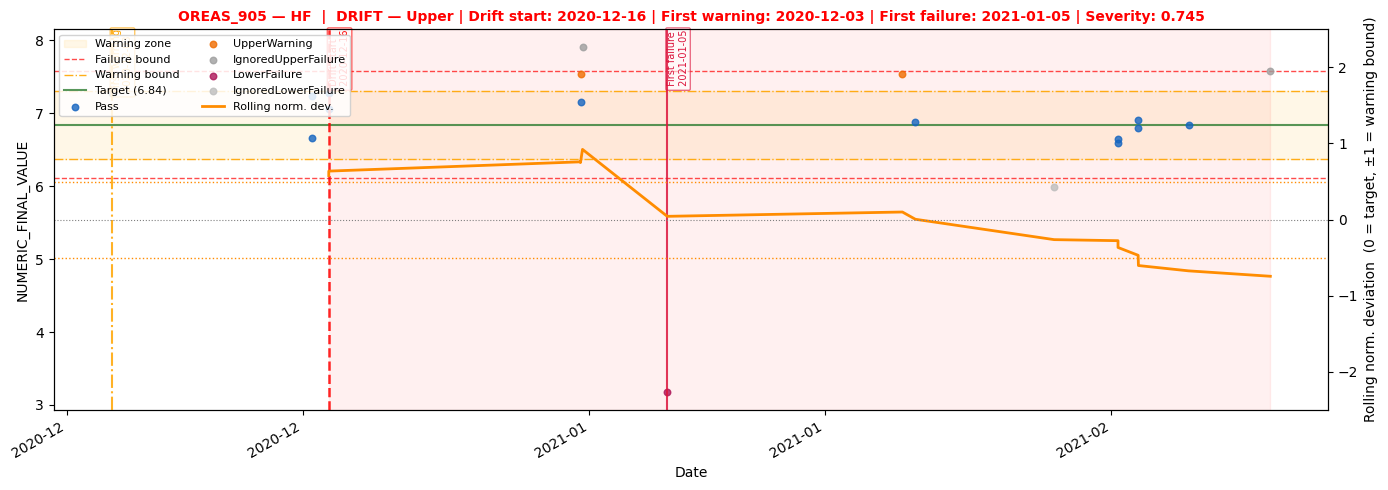

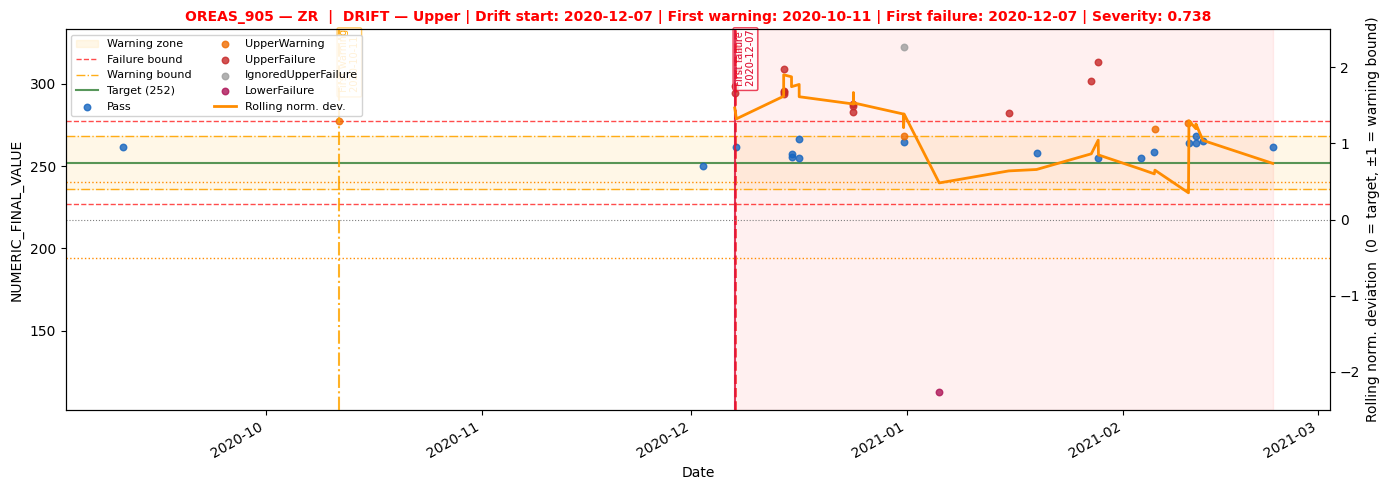

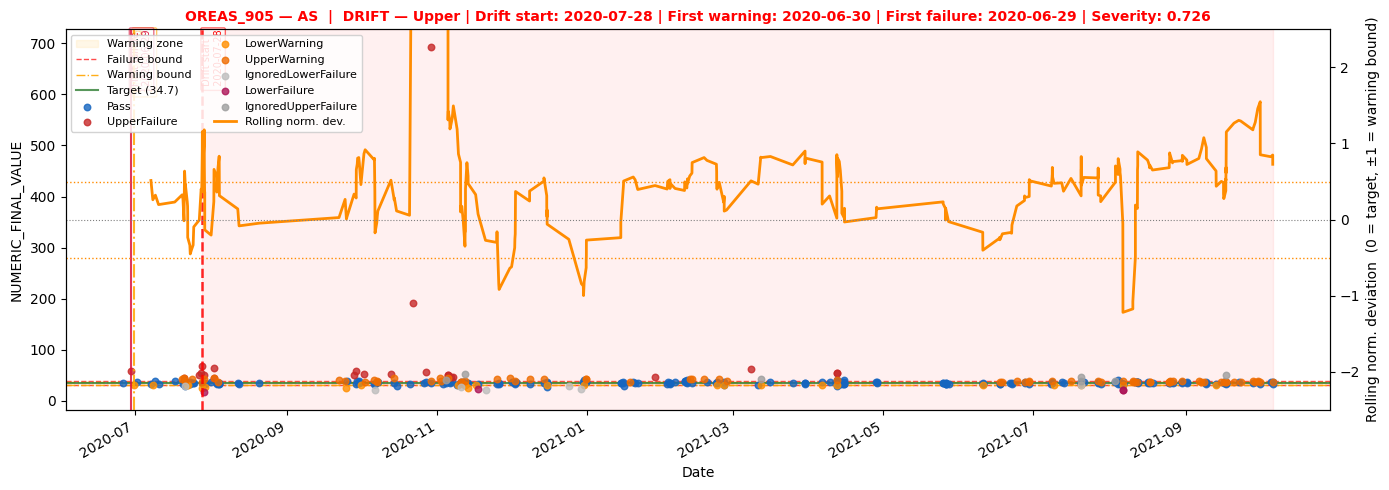

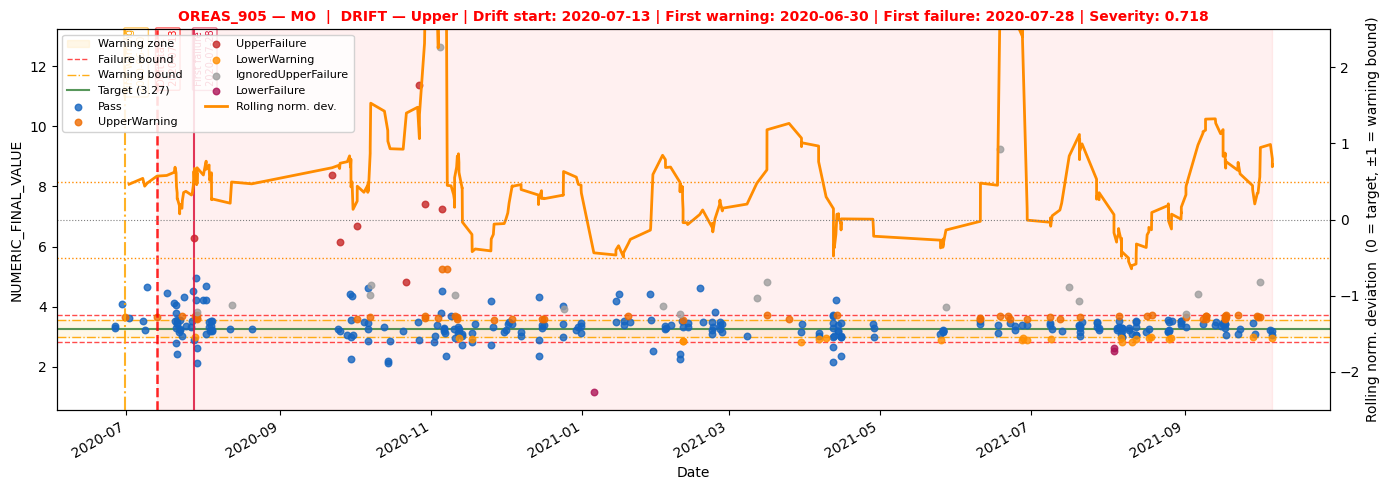

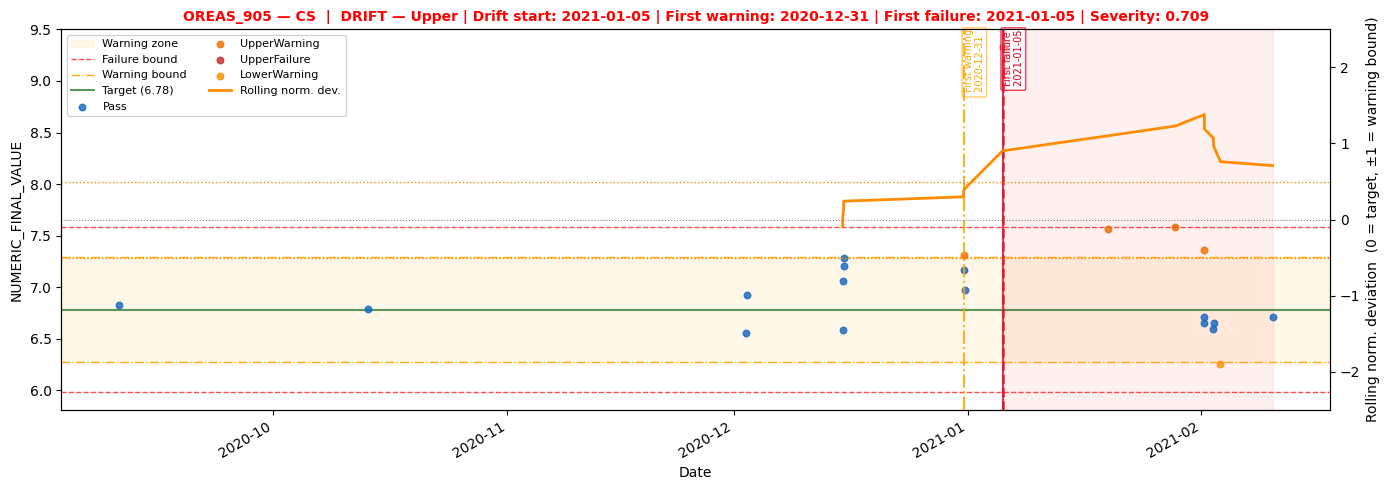

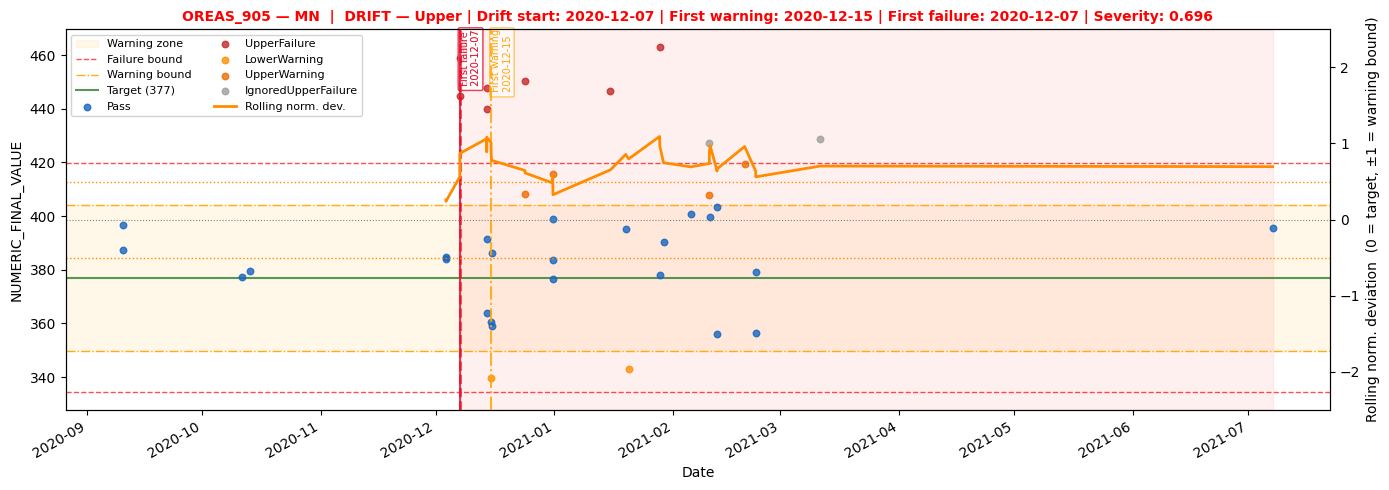

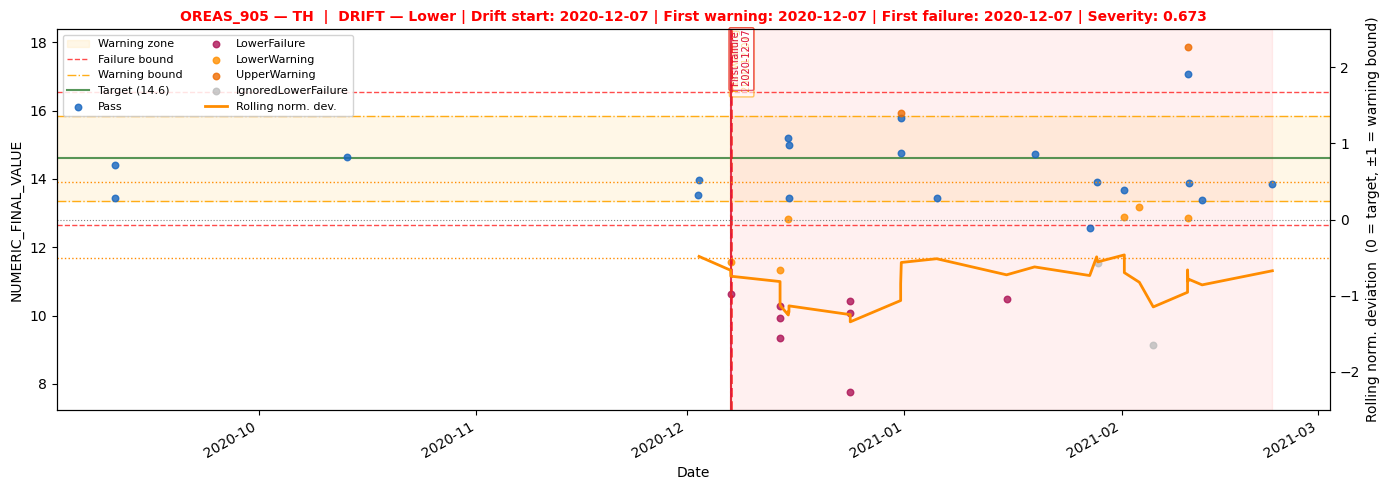

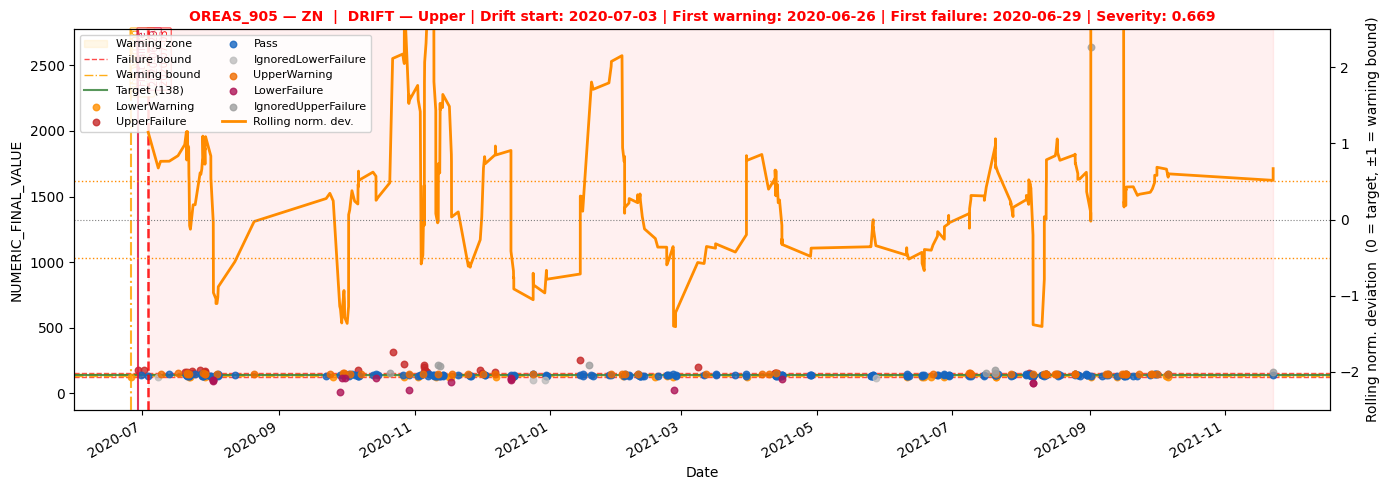

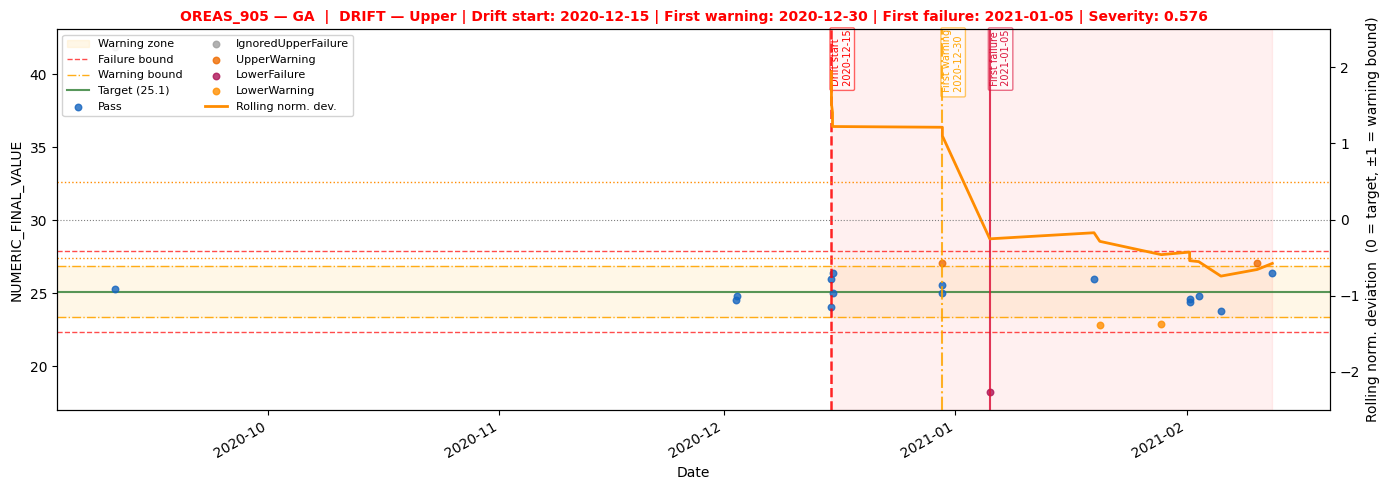

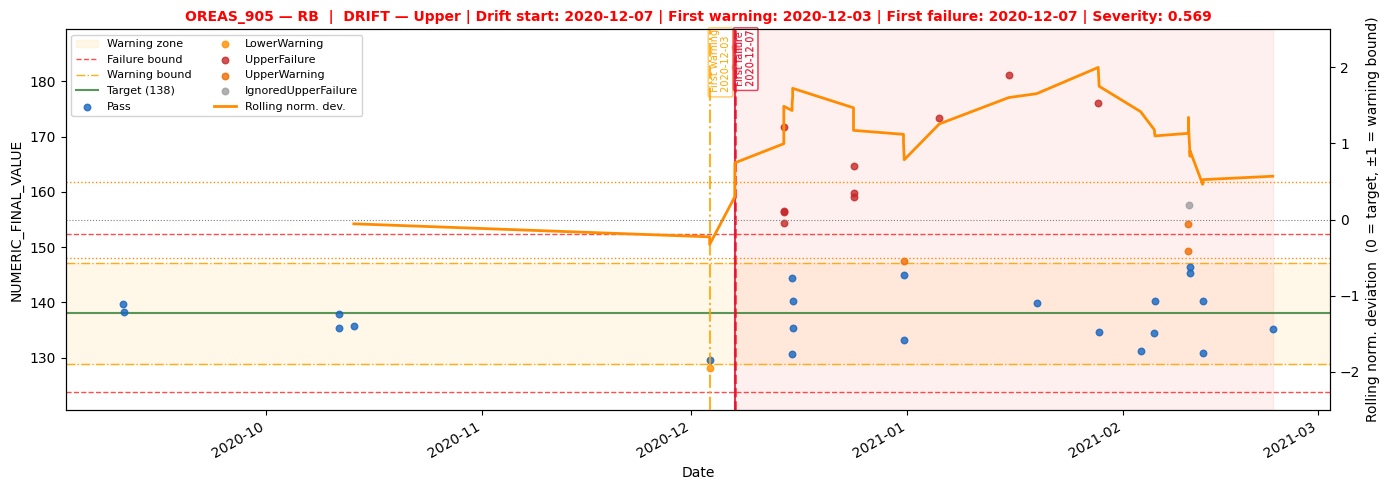

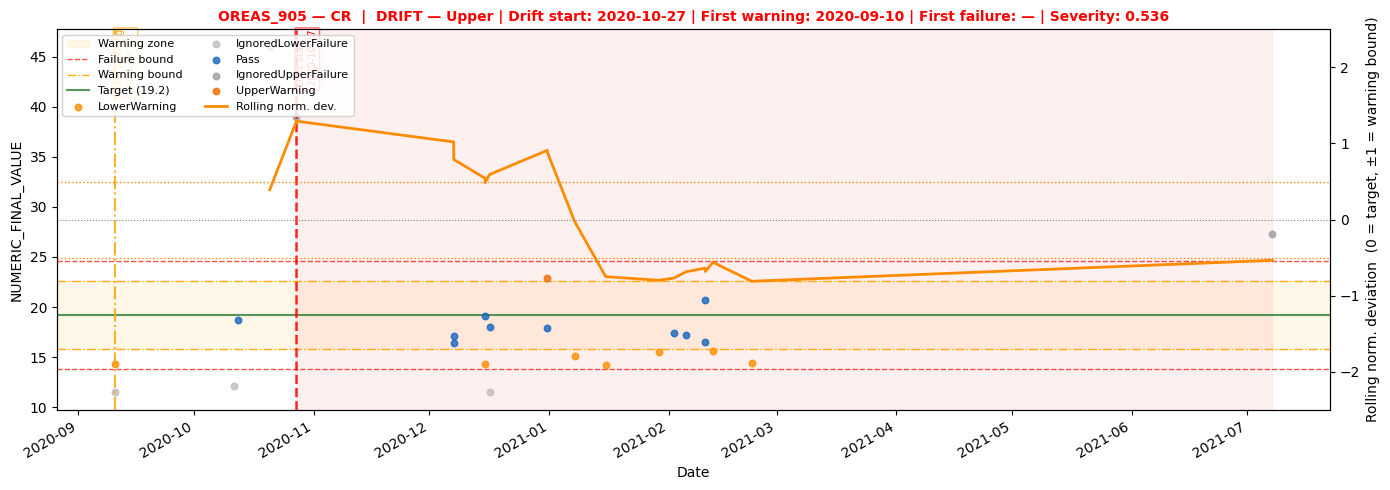

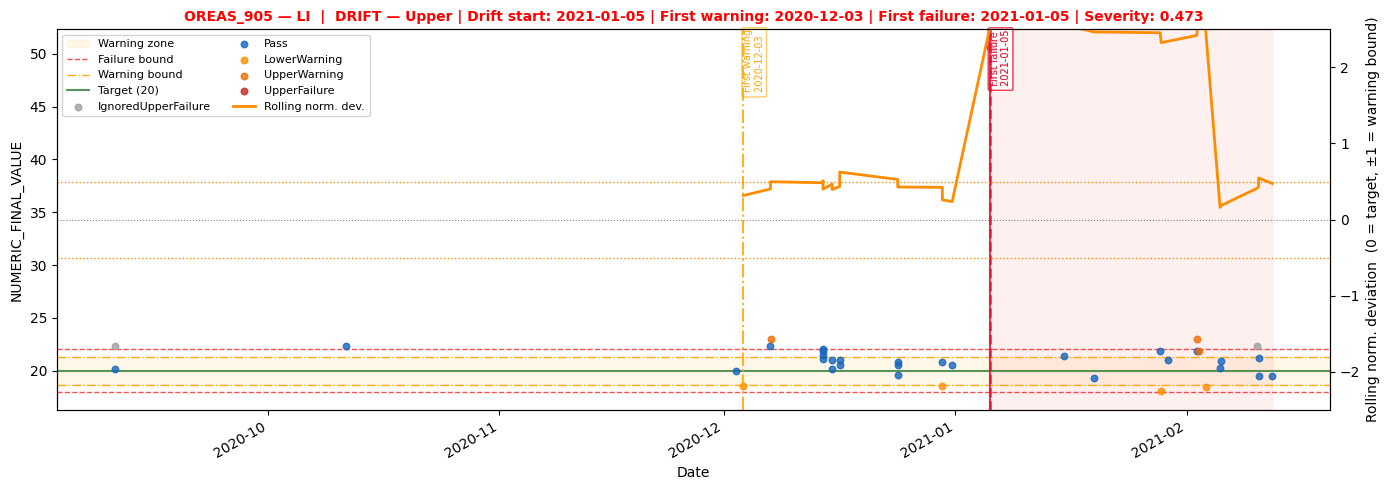

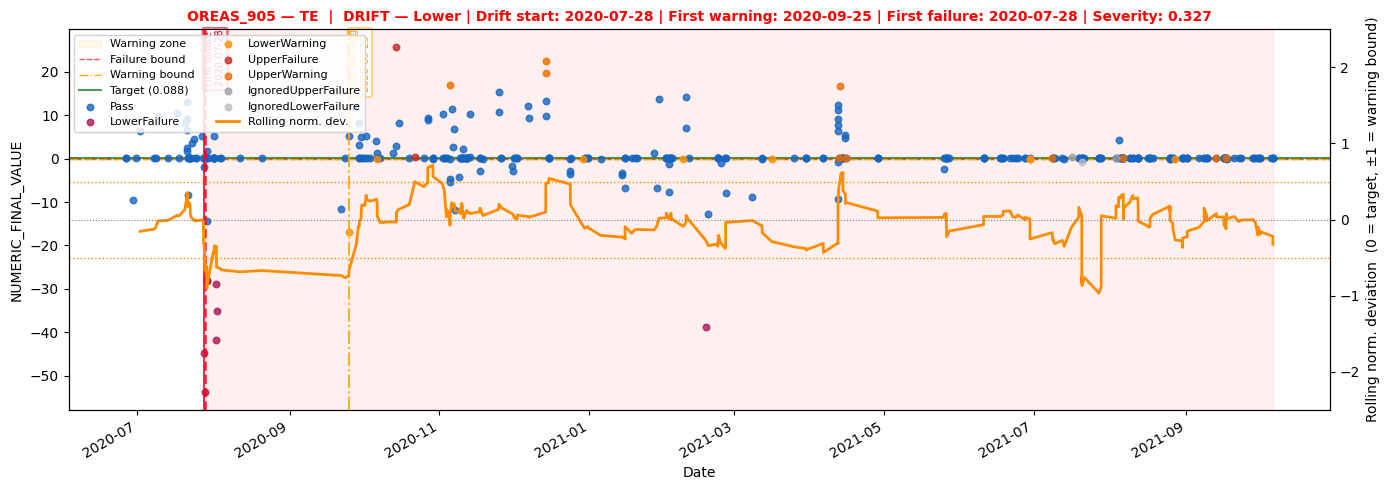

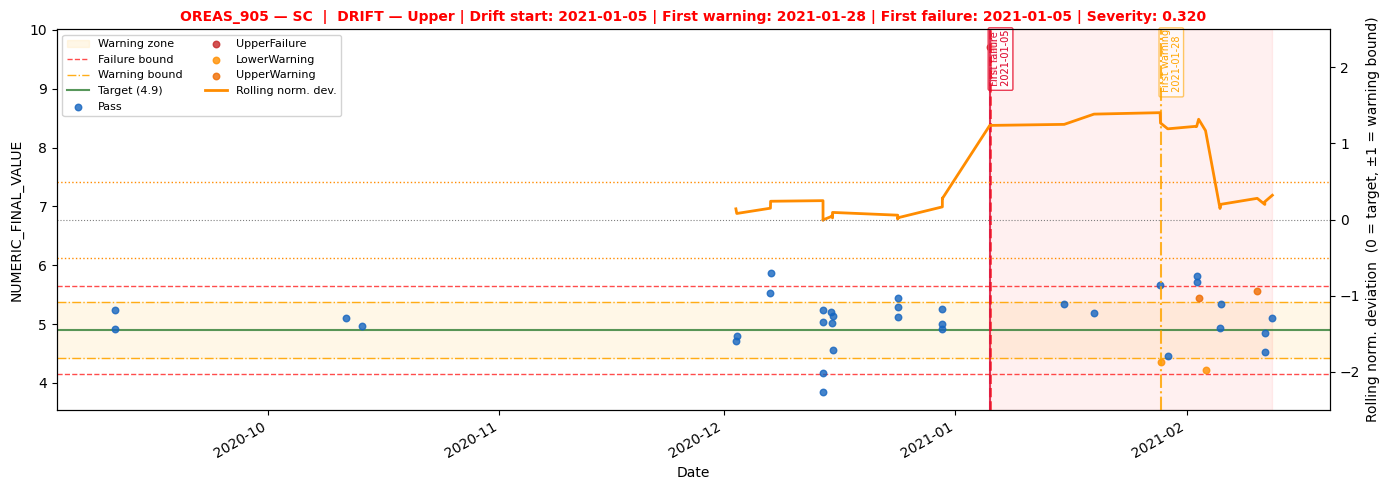

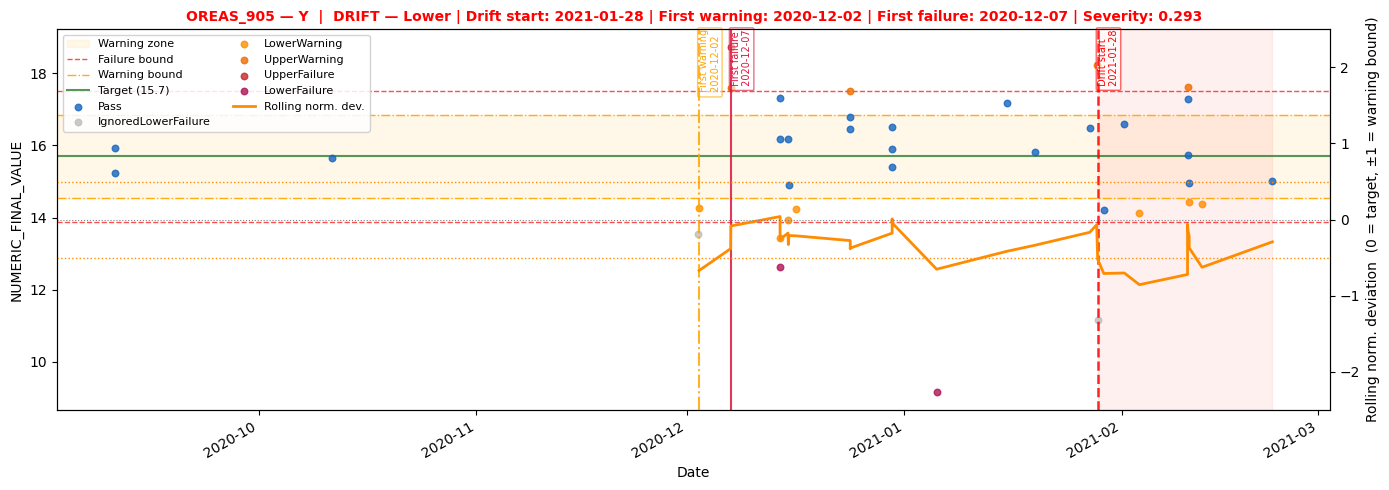

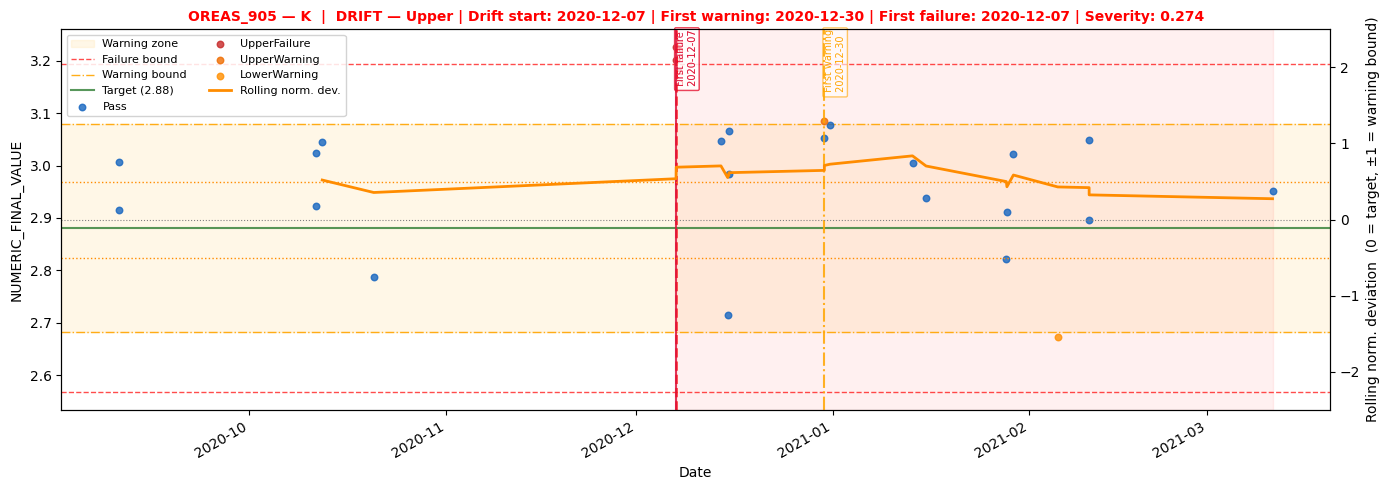

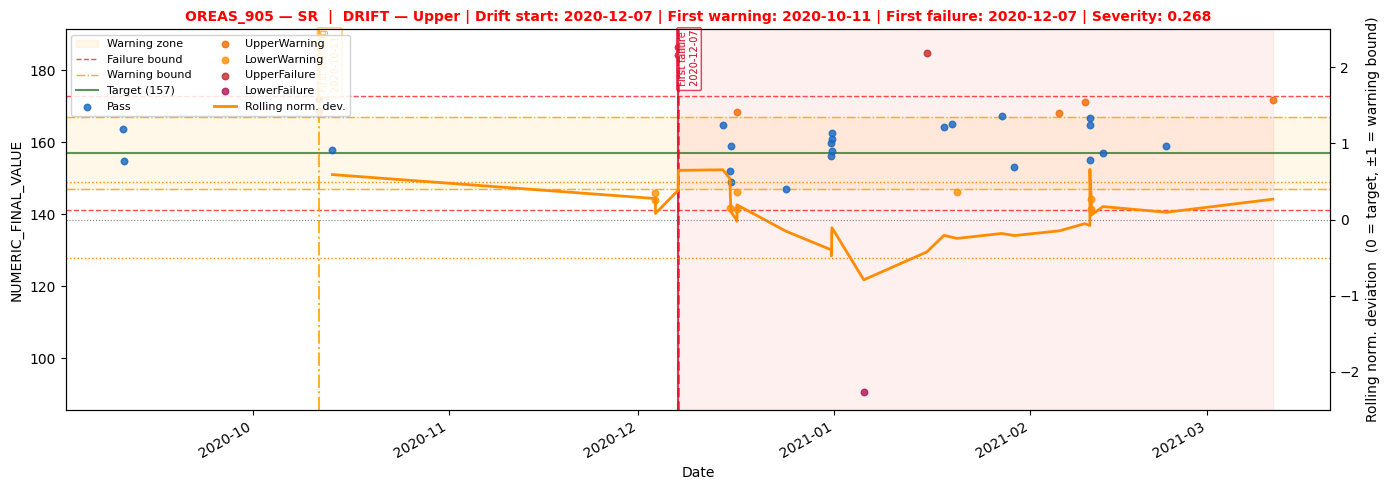

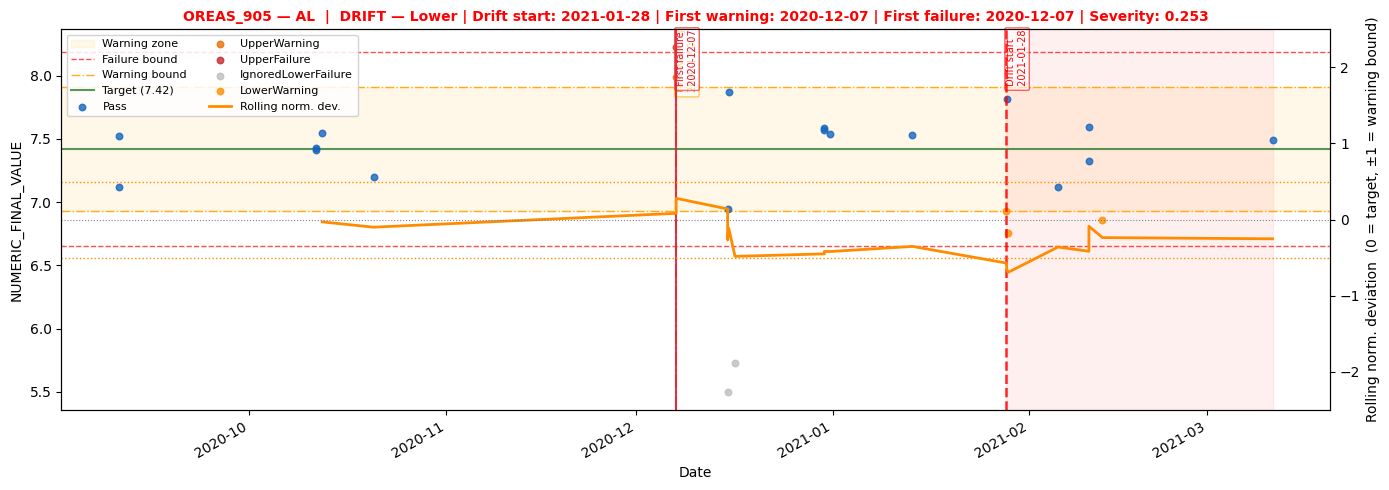

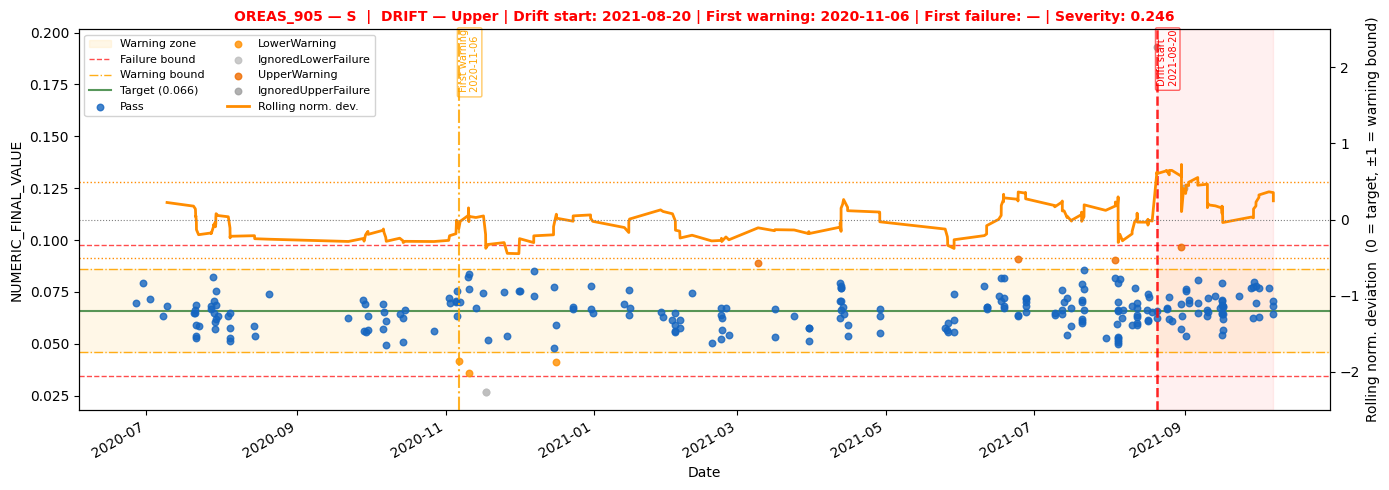

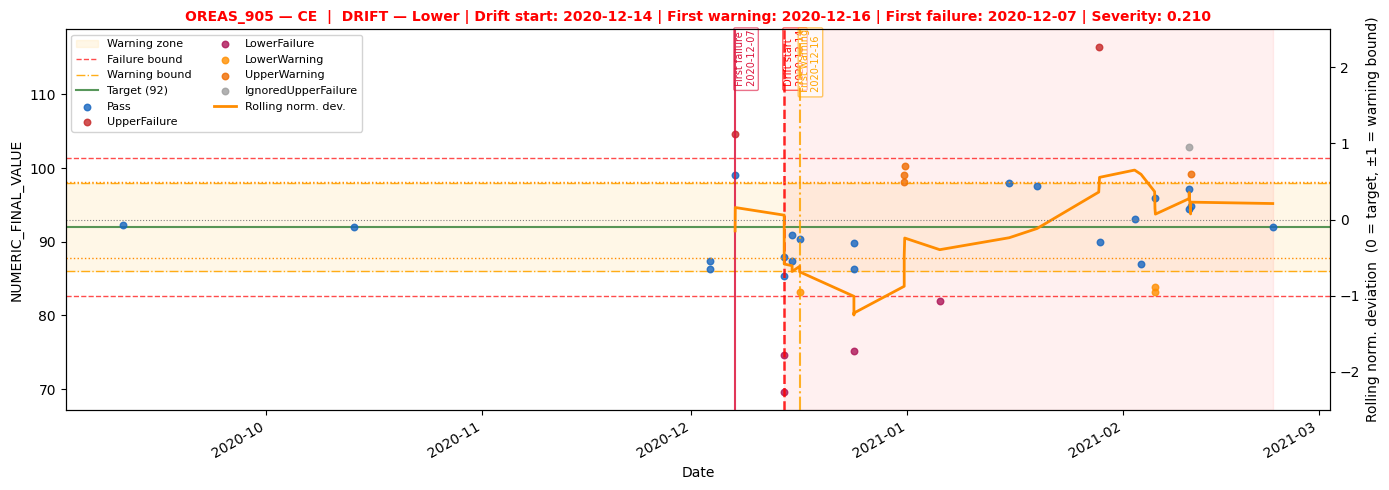

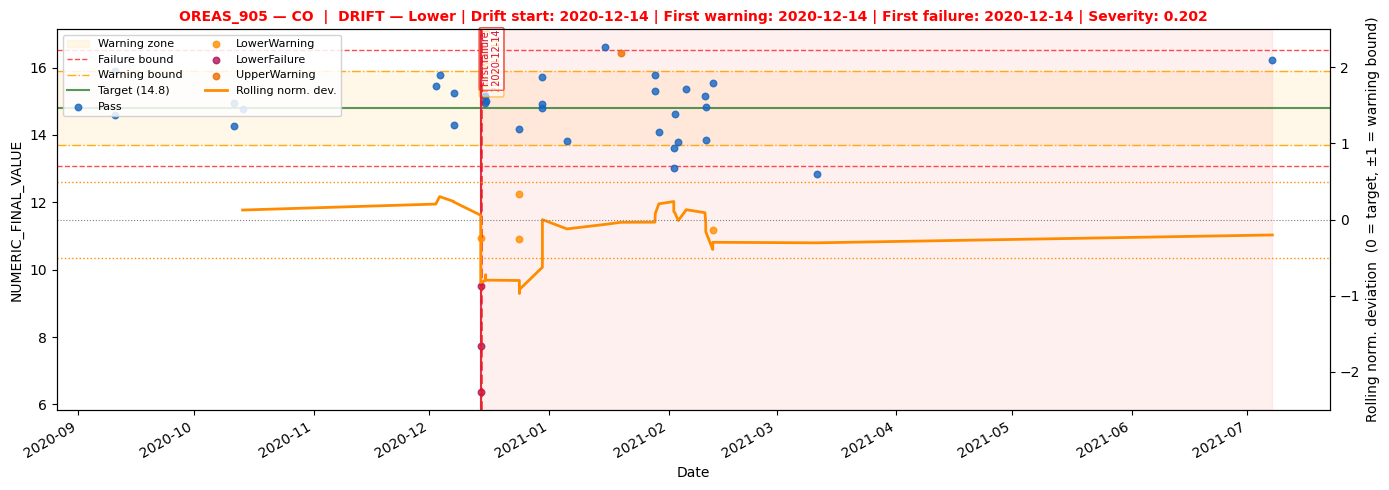

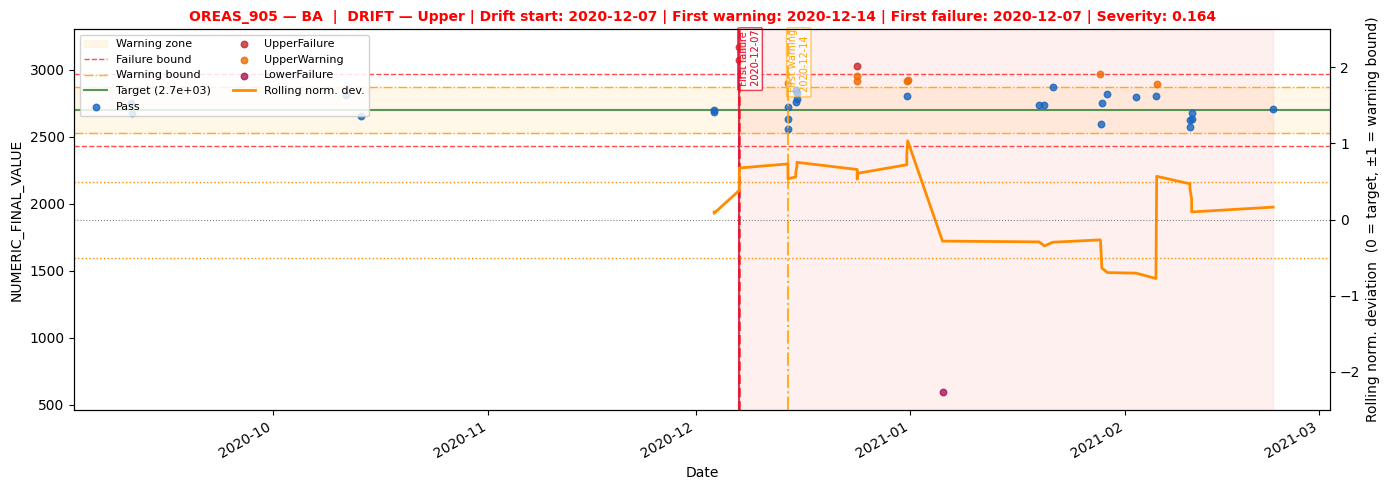

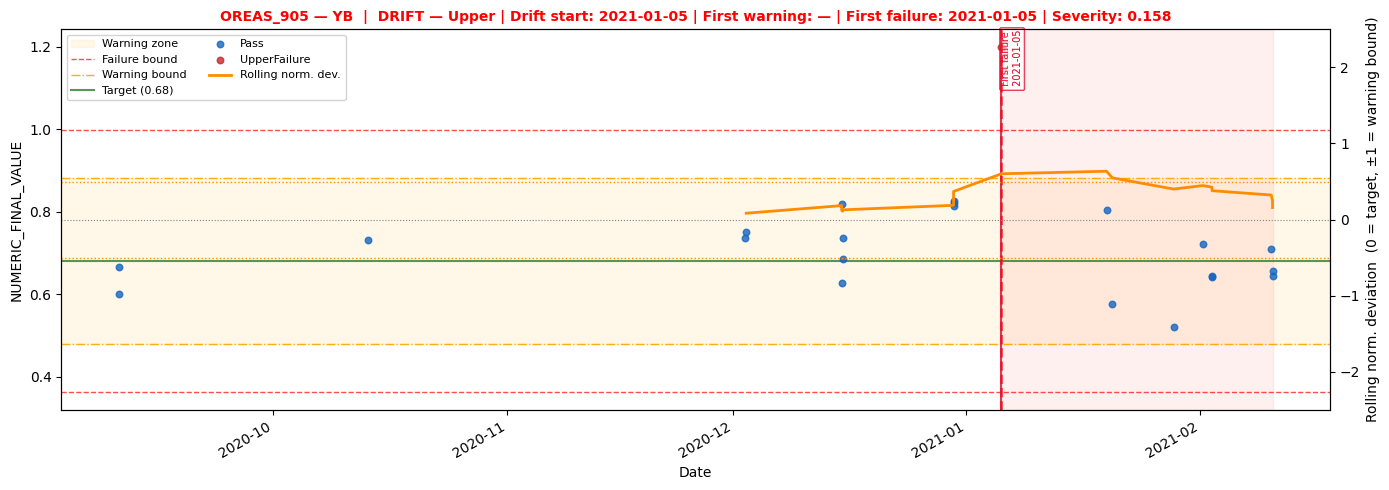

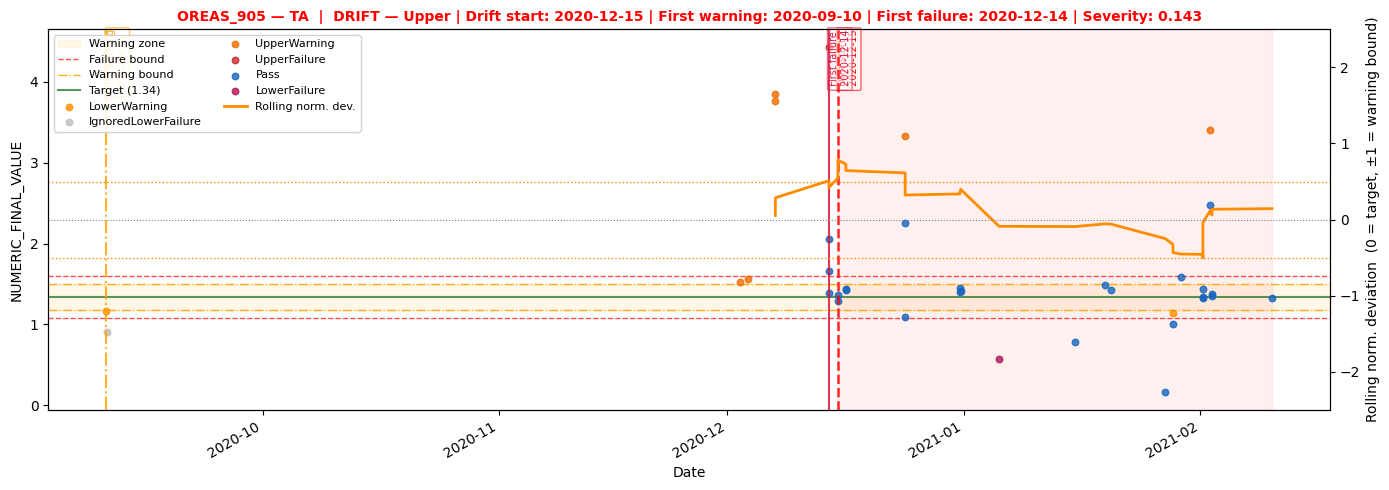

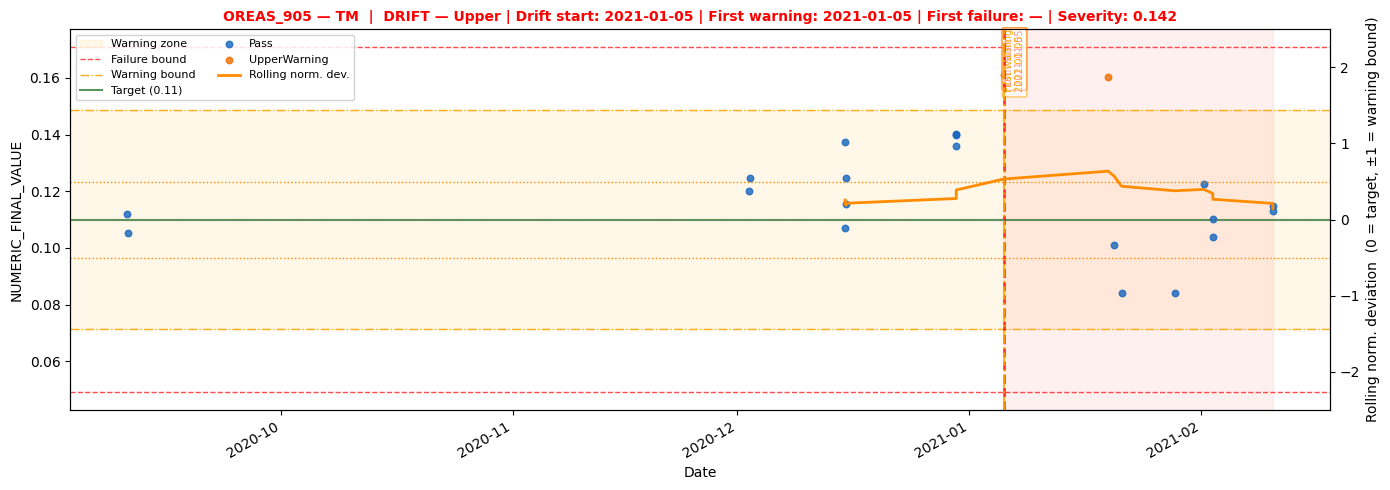

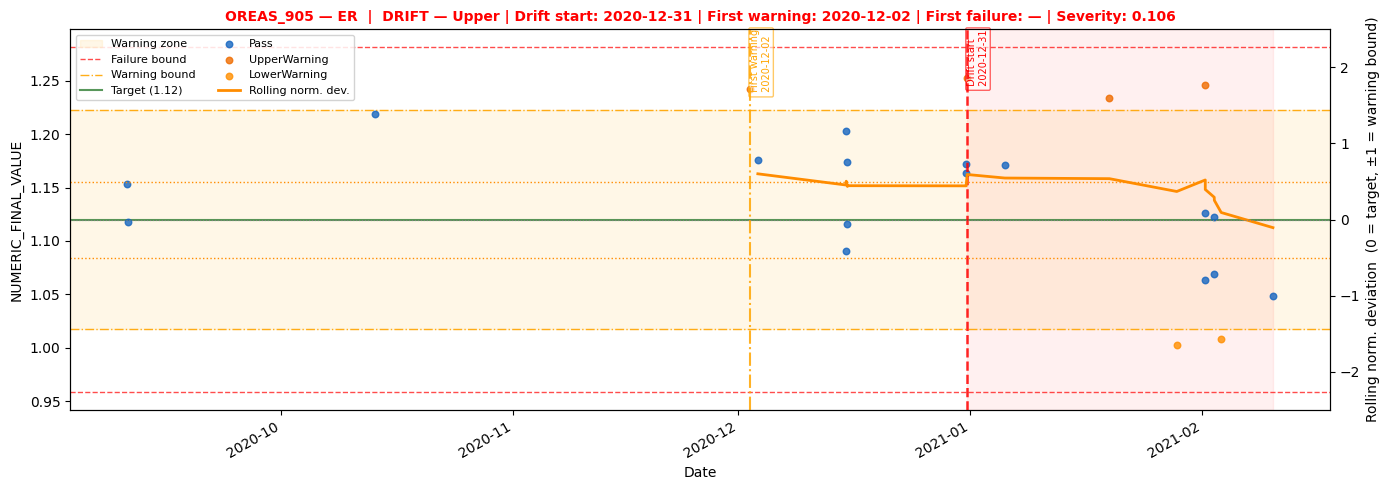

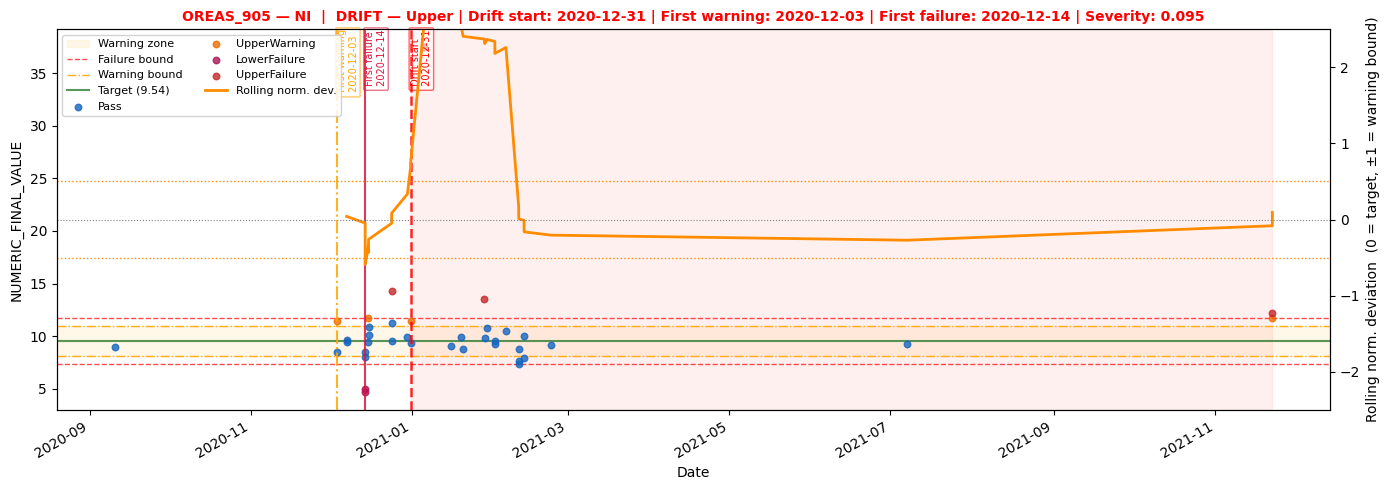

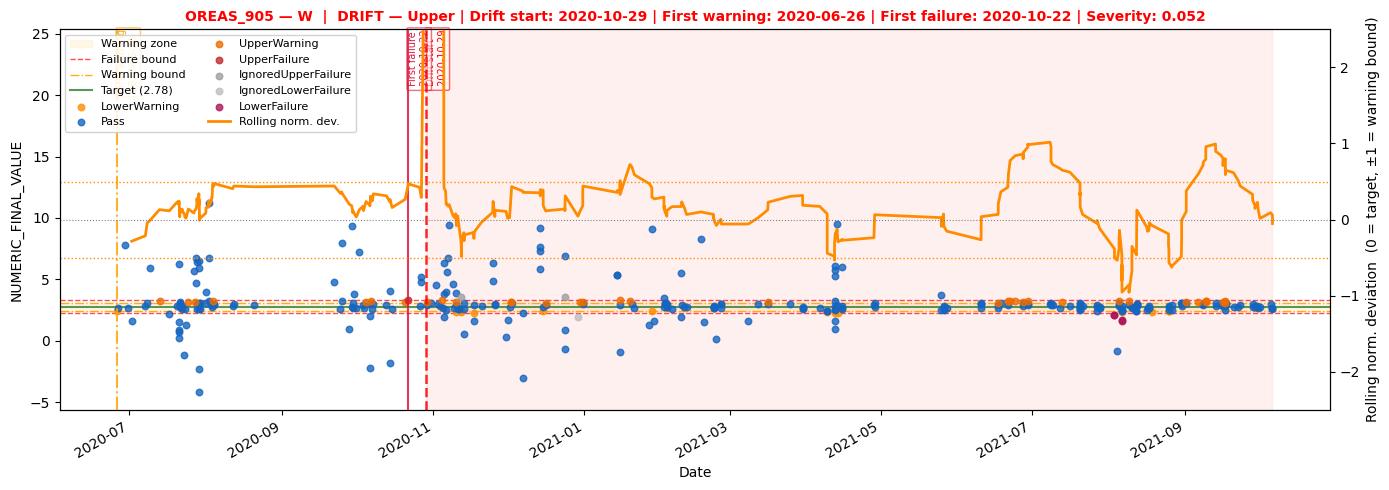

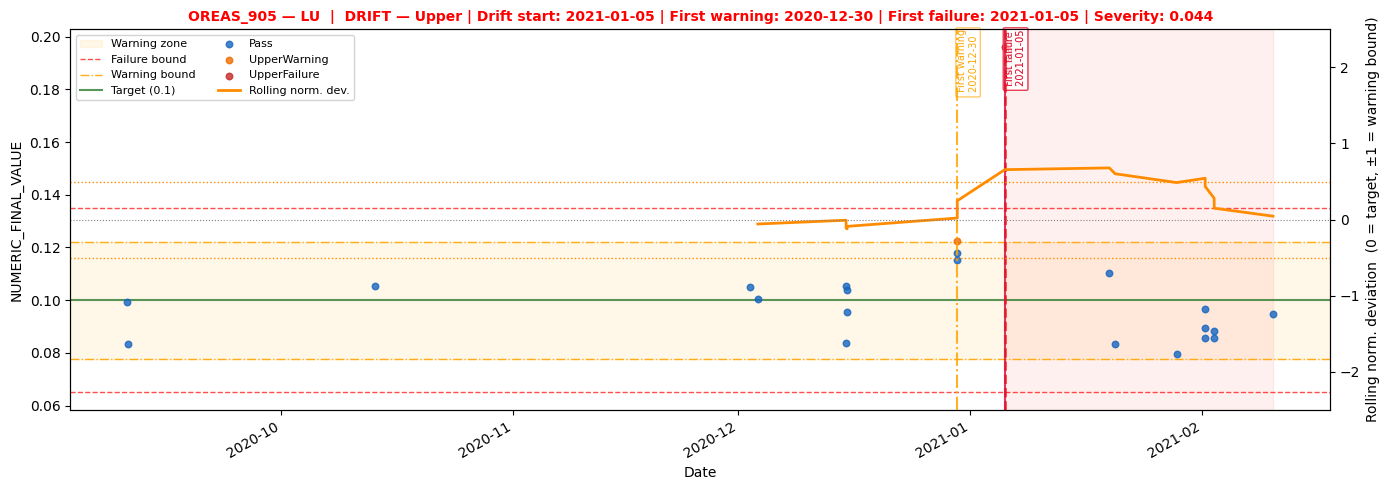

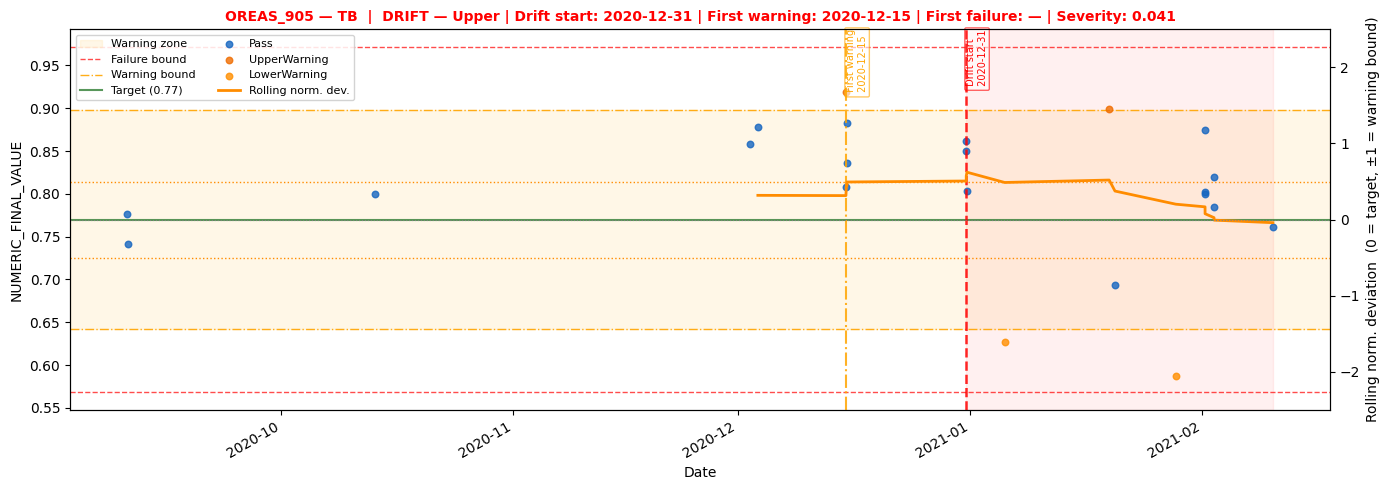

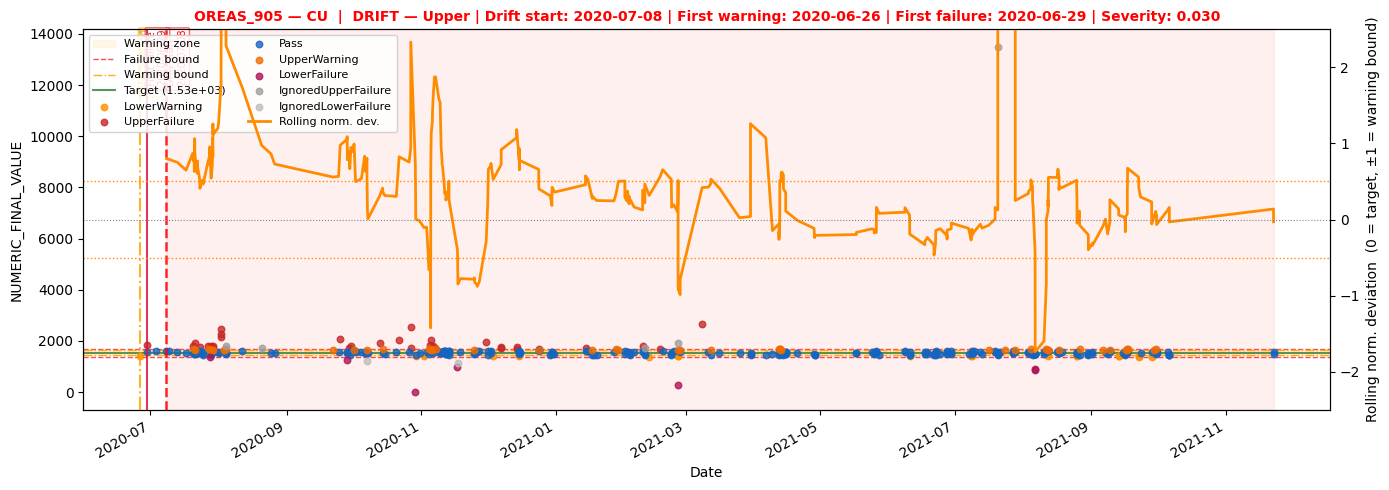

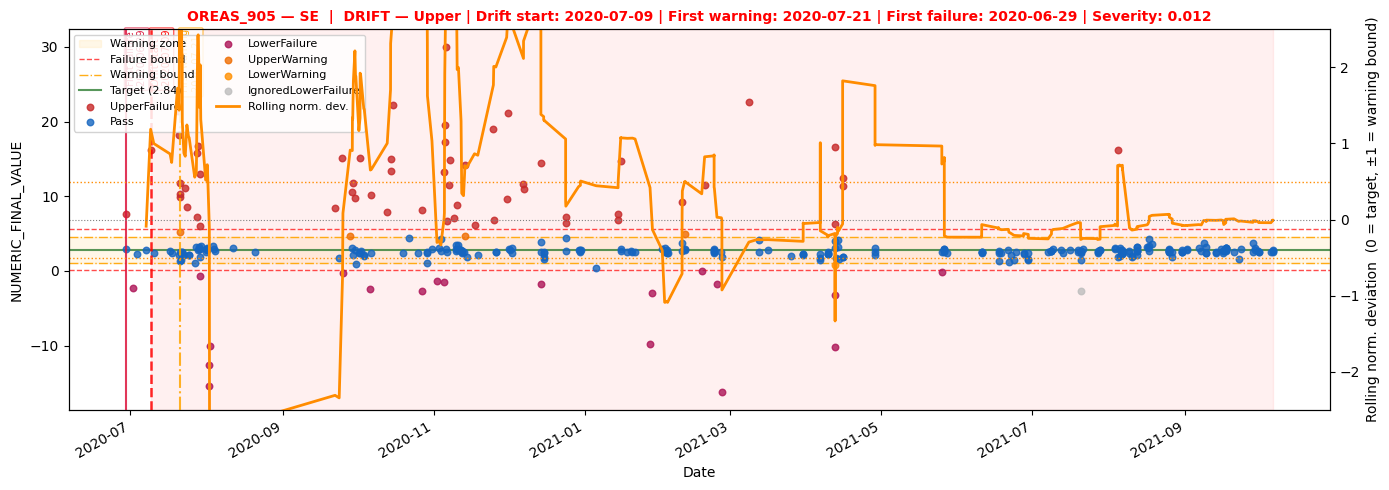

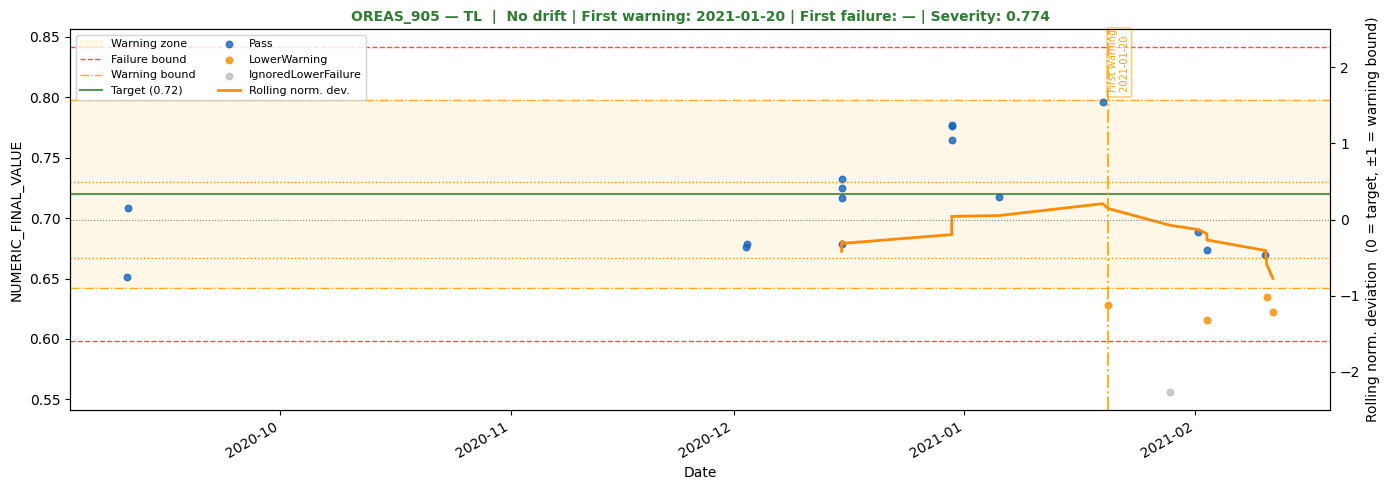

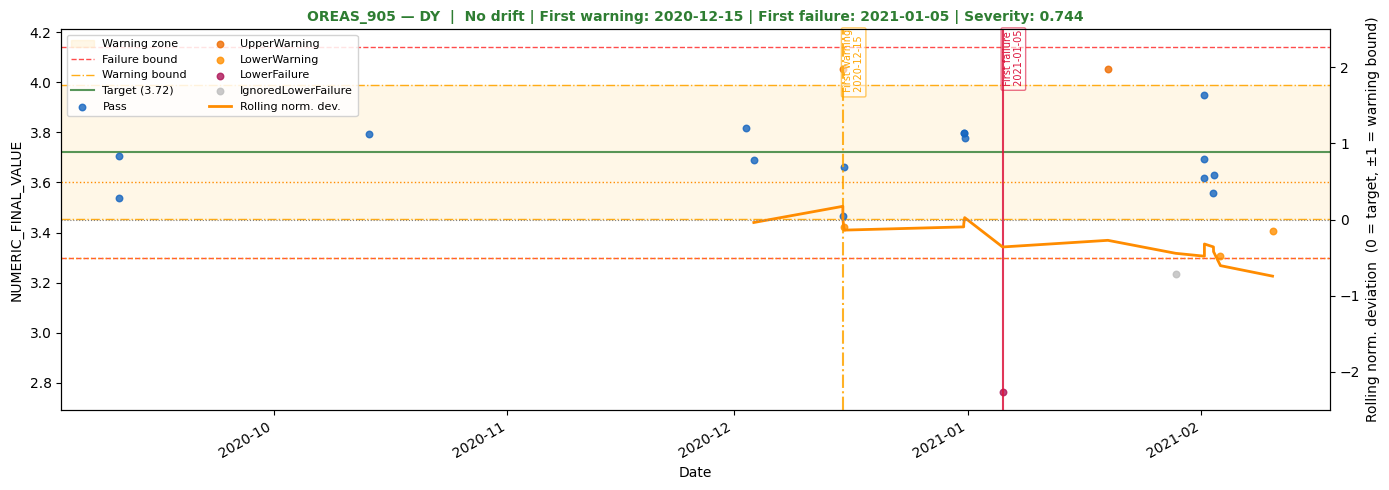

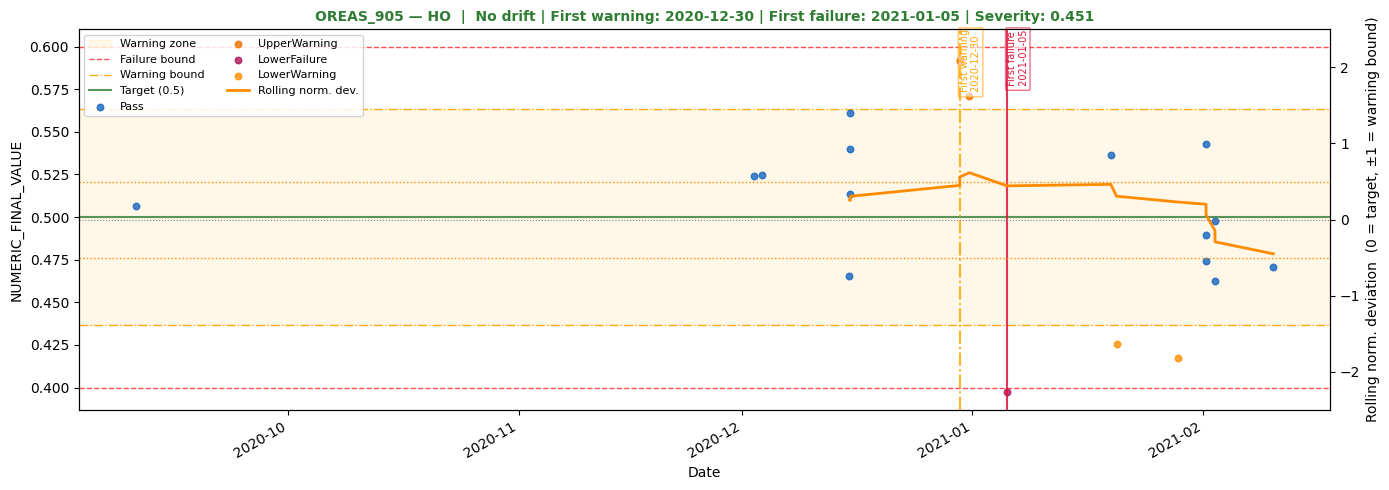

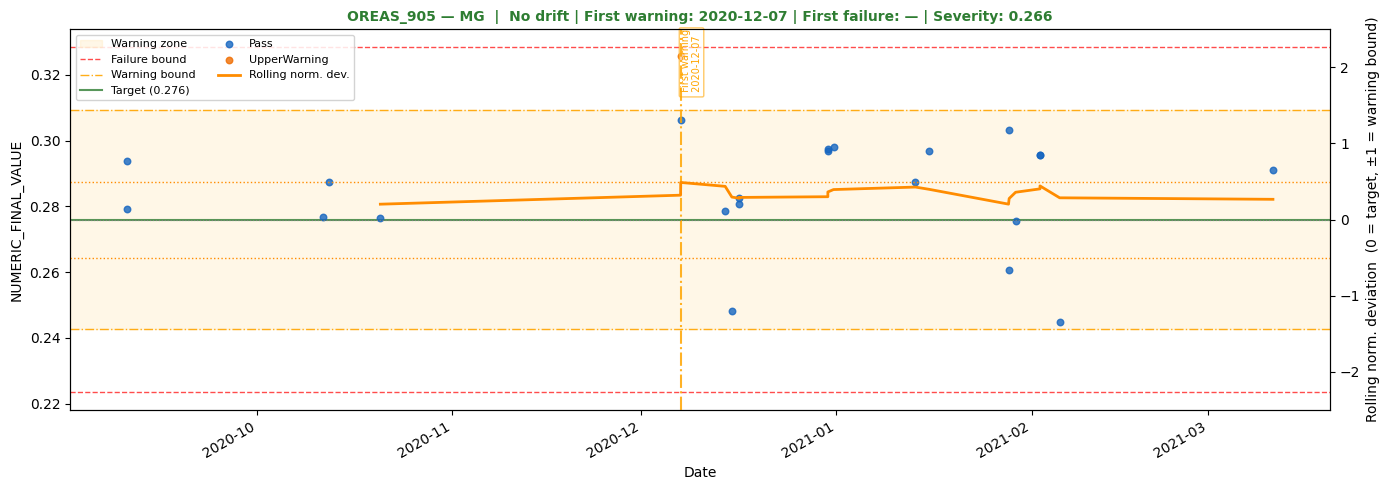

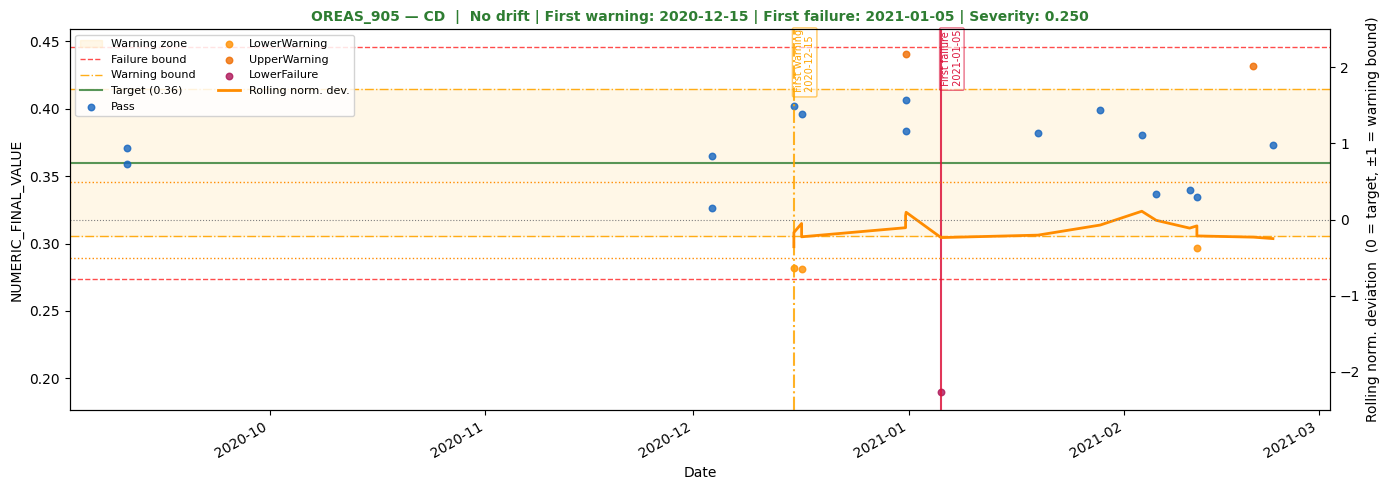

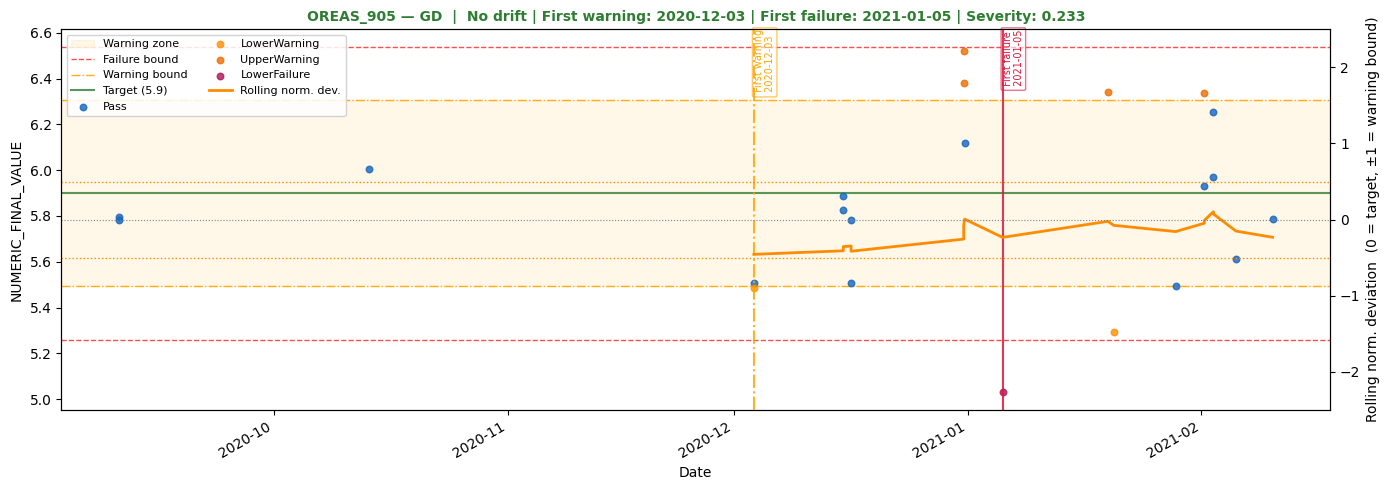

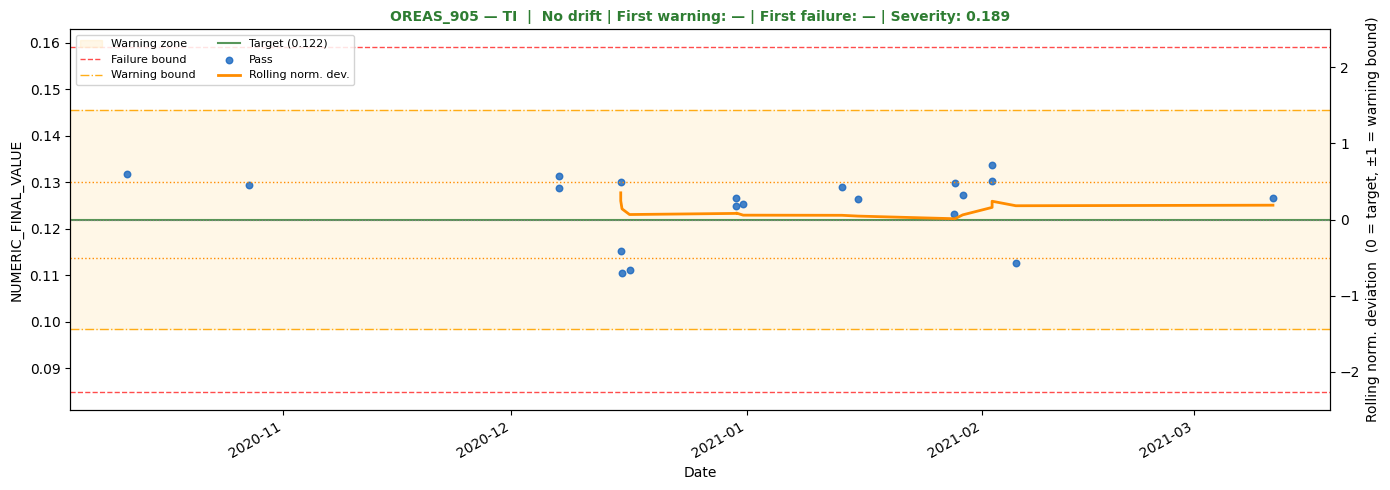

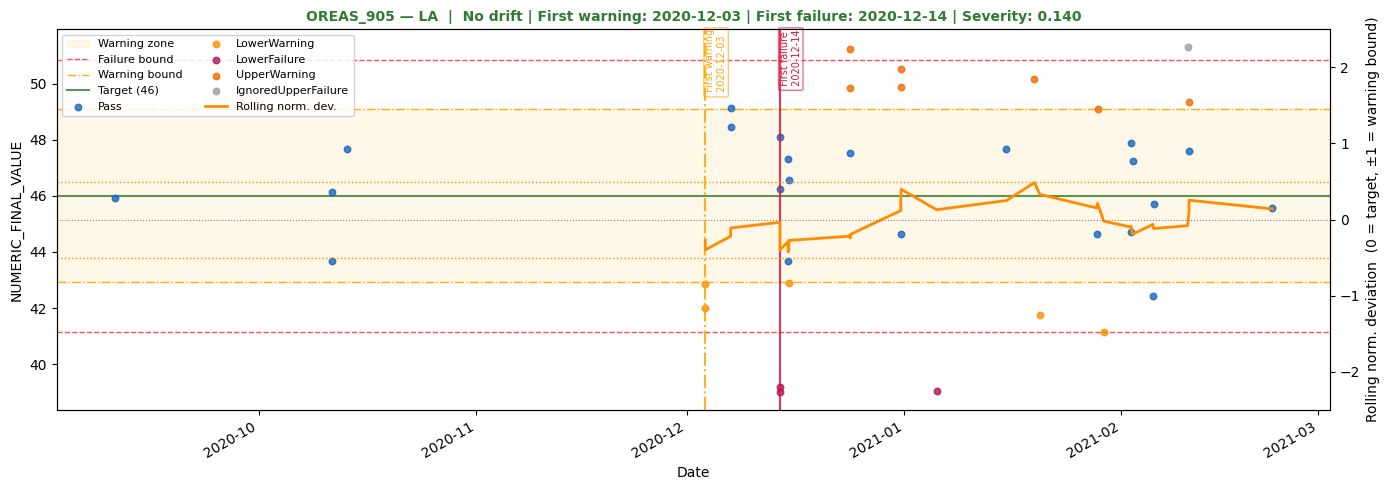

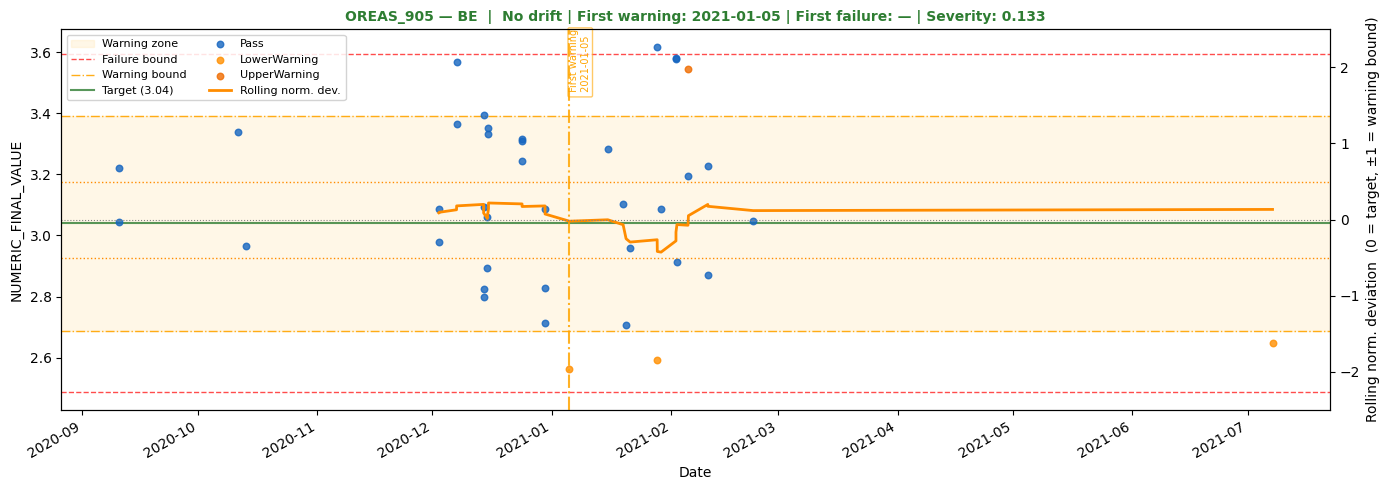

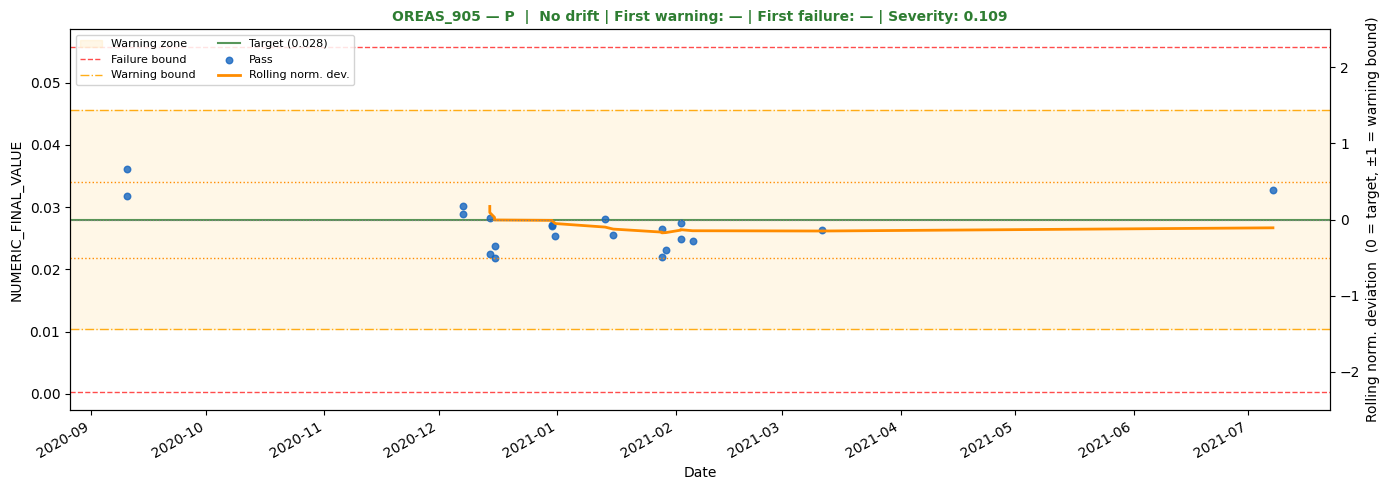

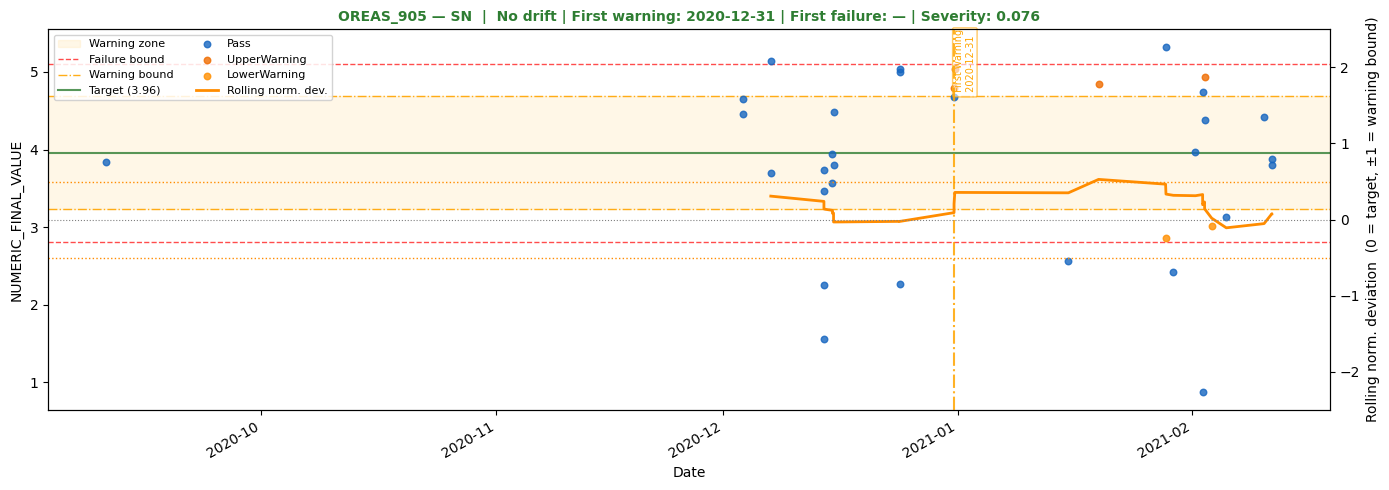

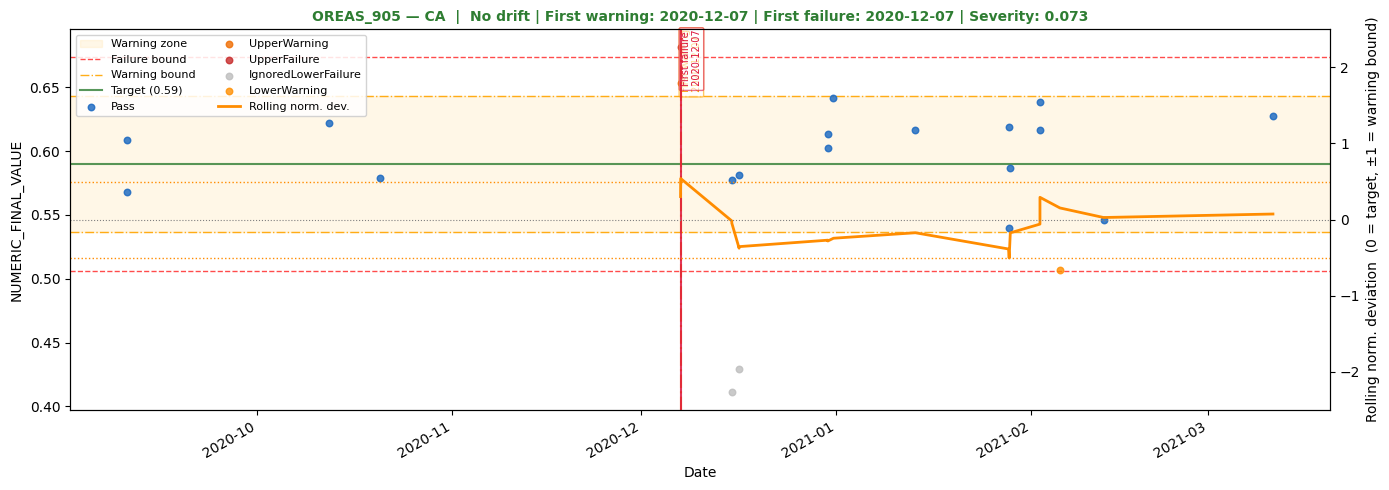

In [9]:
# ── Plot drifting analytes first, then clean ones ────────────────────────────
for _, row in summary.iterrows():
    analyte   = row["ANALYTE_CODE"]
    adf       = analyte_data[analyte]
    drift_info = row.to_dict()

    plot_analyte_drift(
        adf,
        analyte      = analyte,
        std_lot_code = STD_LOT_CODE,
        drift_info   = drift_info,
        drift_threshold = DRIFT_THRESHOLD,
    )

## 6. Export Results

In [10]:
out_path = Path(f"drift_results_{STD_LOT_CODE}.csv")
summary.drop(columns=[]).to_csv(out_path, index=False)
print(f"Saved → {out_path}")

Saved → drift_results_OREAS_905.csv
